# StageBridge: Truth-First Research Frontend

This notebook is the audited research frontend for the active StageBridge v1 path. It is intentionally organized as a numbered protocol so that a reader can trace what was done, what came out of each step, what quality-control criteria were checked, and what output feeds the next stage of the model.

The notebook stays thin in one specific sense: the scientific logic lives in the package under `stagebridge/`. But it is intentionally thick as a research surface. Every major transformation is run or called visibly here, and every major result is paired with tables, figures, and QC checks before moving downstream.

The scientific question remains: **Which within-lung LUAD initiation stage transitions are niche-gated, and how is that gating modulated by evolutionary state?** The current LUAD ladder is `Normal -> AAH -> AIS -> MIA -> LUAD`, with the two prioritized edges `AAH -> AIS` and `AIS -> MIA`.


## Step 1. Configure Run

**Purpose.** Set the active dataset, spatial provider defaults, context mode, edge, and training profile before any biology is touched. This cell should make the run contract explicit, not hidden in downstream code.

**Input.** The normalized repo config tree under `configs/`, especially `configs/default.yaml` and the scoped component configs.

**Output.** One composed config object, plus an immediately readable run summary.

**QC checks.** Confirm the edge, mode, provider, seed, and training profile are exactly what you intend before spending time on alignment or spatial mapping.

**Relevant papers.** HLCA-aligned reference logic is surfaced in later steps; transformer context models are motivated by [Set Transformer](docs/papers/Set%20Transformer%20A%20Framework%20for%20Attention-based%20Permutation-Invariant%20Neural%20Networks.pdf), [Deep Sets](docs/papers/Deep%20Sets.pdf), and [Transformers in single-cell omics](docs/papers/Transformers%20in%20single-cell%20omics%20a%20review%20and%20new%20perspectives.pdf).

**Next step.** Validate the environment and asset paths so the notebook fails early if the dataset or registry layout is wrong.


In [1]:
import importlib
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

import stagebridge.notebook_api as notebook_api
import stagebridge.viz.research_frontend as research_frontend
importlib.reload(notebook_api)
importlib.reload(research_frontend)

from stagebridge.data.luad_evo.metadata import resolve_luad_evo_paths
from stagebridge.evaluation.transformer_tuning import run_set_only_optuna_study
from stagebridge.notebook_api import (
    apply_selected_provider,
    build_biology_summary_table,
    build_context_summary_table,
    build_dataset_preprocessing_table,
    build_gate_ready_table,
    build_provider_benchmark_table,
    build_reference_evaluation_table,
    build_reference_label_table,
    build_reference_summary_table,
    build_spatial_provider_agreement_table,
    build_spatial_provider_metric_table,
    build_spatial_provider_table,
    build_spatial_summary_table,
    build_step_status_table,
    build_transition_summary_table,
    compose_config,
    run_data_preprocessing_overview,
    run_provider_benchmark,
    run_spatial_provider_ladder,
)
from stagebridge.pipelines.run_context_model import run_context_model
from stagebridge.pipelines.run_evaluation import run_evaluation
from stagebridge.pipelines.run_reference import run_reference
from stagebridge.pipelines.run_spatial_mapping import run_spatial_mapping
from stagebridge.pipelines.run_transition_model import run_transition_model
from stagebridge.results import (
    ensure_registry_files,
    load_current_scratch_run,
    read_results_registry,
    write_pipeline_scratch_run,
)
from stagebridge.viz.research_frontend import (
    configure_research_style,
    plot_biological_insight_frontend,
    plot_context_frontend,
    plot_provider_benchmark_frontend,
    plot_reference_frontend,
    plot_snrna_preprocessing_frontend,
    plot_spatial_mapping_frontend,
    plot_spatial_preprocessing_frontend,
    plot_spatial_provider_abundance_frontend,
    plot_spatial_provider_comparison_frontend,
    plot_spatial_provider_maps_frontend,
    plot_transition_frontend,
    plot_wes_preprocessing_frontend,
)

configure_research_style()

cfg = compose_config(
    "default",
    overrides=[
        "data=luad_evo",
        "train=medium",
        "evaluation=baseline",
        "context_model=typed_hierarchical_transformer",
        "transition_model.active_edge=[AAH,AIS]",
    ],
)

run_contract = pd.DataFrame(
    [
        {"field": "run_name", "value": cfg.run_name},
        {"field": "seed", "value": int(cfg.seed)},
        {"field": "train_profile", "value": getattr(cfg.train, 'profile', 'custom')},
        {"field": "spatial_provider", "value": cfg.spatial_mapping.method},
        {"field": "selected_provider", "value": getattr(cfg.spatial_mapping, 'selected_provider', cfg.spatial_mapping.method)},
        {"field": "context_mode", "value": cfg.context_model.mode},
        {"field": "active_edge", "value": '->'.join(cfg.transition_model.active_edge)},
        {"field": "wes_enabled", "value": bool(cfg.transition_model.wes_regularizer.enabled)},
        {"field": "sigma", "value": float(cfg.transition_model.schrodinger_bridge.sigma)},
    ]
)

display(run_contract)


2026-03-09 01:11:05 | INFO     | stagebridge.data.luad_evo.visium | squidpy 1.8.1 available — using sq.read.visium() as primary loader.


,field,value
0,run_name,stagebridge_v1
1,seed,42
2,train_profile,medium
3,spatial_provider,tangram
4,selected_provider,tangram
5,context_mode,typed_hierarchical_transformer
6,active_edge,AAH->AIS
7,wes_enabled,True
8,sigma,0.1


## Step 2. Validate Environment and Asset Paths

**Purpose.** Check that the notebook is pointing at the real LUAD evolution assets, the lightweight scratch/registry result system is available, and the active config resolves to the expected files.

**Input.** The composed config from Step 1 and the data-path resolver in `stagebridge/data/luad_evo/metadata.py`.

**Output.** A compact asset table, registry bootstrap, and a quick view of recent recorded attempts.

**QC checks.** Confirm the reference latent file, spatial H5AD, and WES table are the assets you actually want to use. If the registry is missing or the paths look wrong, stop here.

**Next step.** Preview the three modalities directly so the raw cohort composition is visible before the HLCA and spatial-mapping branches transform anything.


In [2]:
ensure_registry_files()
paths = resolve_luad_evo_paths(cfg)

asset_table = pd.DataFrame(
    [
        {"asset": "snRNA latent", "path": str(paths.snrna_latent_h5ad), "exists": Path(paths.snrna_latent_h5ad).exists()},
        {"asset": "snRNA raw", "path": str(paths.snrna_h5ad), "exists": Path(paths.snrna_h5ad).exists()},
        {"asset": "Visium", "path": str(paths.spatial_h5ad), "exists": Path(paths.spatial_h5ad).exists()},
        {"asset": "WES", "path": str(paths.wes_features_path), "exists": Path(paths.wes_features_path).exists()},
        {"asset": "HLCA reference", "path": str(paths.hlca_h5ad), "exists": Path(paths.hlca_h5ad).exists()},
    ]
)

display(asset_table)
registry_rows = read_results_registry()
registry_preview = pd.DataFrame(registry_rows).tail(10) if registry_rows else pd.DataFrame()
display(registry_preview)


,asset,path,exists
0,snRNA latent,/mnt/e/StageBridge_data/processed/anndata/snrn...,True
1,snRNA raw,/mnt/e/StageBridge_data/interim/anndata/snrna/...,True
2,Visium,/mnt/e/StageBridge_data/interim/anndata/spatia...,True
3,WES,/mnt/e/StageBridge_data/processed/features/wes...,True
4,HLCA reference,/mnt/e/StageBridge_data/data/reference/hlca/hl...,False


,timestamp,git_commit,git_short_hash,git_branch,experiment_name,mode,stage_edges,split_name,wes_regularizer_enabled,spatial_mapping_method,context_model_mode,status,primary_metric,promoted,scratch_path,milestone_id
33,2026-03-08T02:37:44.837535+00:00,20e0d11e1a1858e58a27e1f0491c9af3fa3573d7,20e0d11,main,mission3_final_gate_summary,scientific_gates,AAH->AIS|AIS->MIA,donor_holdout,no,tangram,set_only,complete,,no,outputs/scratch/current,
34,2026-03-08T04:00:46.350351+00:00,20e0d11e1a1858e58a27e1f0491c9af3fa3573d7,20e0d11,main,AAH_to_AIS,set_only,AAH->AIS,donor_holdout,no,tangram,set_only,complete,26.88287353515625,no,outputs/scratch/current,
35,2026-03-08T04:02:18.139495+00:00,20e0d11e1a1858e58a27e1f0491c9af3fa3573d7,20e0d11,main,AAH_to_AIS,set_only,AAH->AIS,donor_holdout,no,tangram,set_only,complete,28.174846649169922,no,outputs/scratch/current,
36,2026-03-08T04:17:35.991371+00:00,20e0d11e1a1858e58a27e1f0491c9af3fa3573d7,20e0d11,main,AAH_to_AIS,set_only,AAH->AIS,donor_holdout,yes,tangram,set_only,complete,14.287663459777832,no,outputs/scratch/current,
37,2026-03-08T05:04:54.092269+00:00,20e0d11e1a1858e58a27e1f0491c9af3fa3573d7,20e0d11,main,set_only_ais_to_mia_baseline,set_only,AIS->MIA,donor_holdout,no,tangram,set_only,complete,26.628677368164062,no,outputs/scratch/current,
38,2026-03-08T06:11:13.190281+00:00,c28354a529ecd3b014627e455635385f36974ead,c28354a,main,AAH_to_AIS,set_only,AAH->AIS,donor_holdout,no,tangram,set_only,complete,28.19644546508789,no,outputs/scratch/current,
39,2026-03-08T06:12:48.162679+00:00,c28354a529ecd3b014627e455635385f36974ead,c28354a,main,AAH_to_AIS,set_only,AAH->AIS,donor_holdout,no,tangram,set_only,complete,26.964866638183594,no,outputs/scratch/current,
40,2026-03-08T06:58:09.062491+00:00,c28354a529ecd3b014627e455635385f36974ead,c28354a,main,AAH_to_AIS,set_only,AAH->AIS,donor_holdout,no,tangram,set_only,complete,27.445865631103516,no,outputs/scratch/current,
41,2026-03-08T07:04:35.310755+00:00,c28354a529ecd3b014627e455635385f36974ead,c28354a,main,AAH_to_AIS,set_only,AAH->AIS,donor_holdout,no,tangram,set_only,complete,27.001239776611328,no,outputs/scratch/current,
42,2026-03-08T19:40:05.660545+00:00,b9b0d61ed22cb065dd9940e58832f9f8396c3f71,b9b0d61,main,AAH_to_AIS,typed_hierarchical_transformer,AAH->AIS,donor_holdout,yes,tangram,set_only,complete,1.23,no,outputs/scratch/current,


## Step 3. Dataset Preprocessing and Cohort Preview

**Purpose.** Show the three active modalities before reference alignment or spatial deconvolution. This cell should answer: what cohort is actually in memory, how are stages represented, what does the snRNA latent look like, what does the Visium geometry look like, and what does the WES table contain?

**Input.** The current LUAD evolution assets for snRNA-seq, Visium spatial transcriptomics, and WES.

**Output.** A dataset summary table, a stage-colored PCA and HLCA-colored UMAP for the snRNA latent, a Visium stage layout plus raw feature plots for epithelial/stromal/immune/vascular markers, and a compact WES preview with TMB plus an oncoprint-style mutation heatmap.

**QC checks.** Look for obvious stage imbalance, missing modalities, implausible spatial geometry, or a WES table that has too little donor-stage support to regularize transport later.

**Relevant papers.** The spatial and temporal motivation is aligned with [Temporal tissue dynamics from a spatial snapshot](docs/papers/Temporal%20tissue%20dynamics%20from%20a%20spatial%20snapshot.pdf), while the spatial mapping branches used later are motivated by [Tangram](docs/papers/Deep%20learning%20and%20alignment%20of%20spatially%20resolved%20single-cell%20transcriptomes%20with%20Tangram.pdf), [TACCO](docs/papers/TACCO%20unifies%20annotation%20transfer%20and%20decomposition%20of%20cell%20identities%20for%20single-cell%20and%20spatial%20omics.pdf), and [DestVI](docs/papers/DestVI%20identifies%20continuums%20of%20cell%20types%20in%20spatial%20transcriptomics%20data.pdf).

**Next step.** Run the active HLCA reference-latent branch and then audit whether the reference projection is trustworthy enough to use downstream.


/home/ajbook/micromamba/envs/stagebridge/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,modality,n_obs,n_features,n_donors,n_samples,n_stage_groups,source_path
0,snRNA-seq,800,30,23,70,5,/mnt/e/StageBridge_data/processed/anndata/snrn...
1,Visium,800,18120,25,56,5,/mnt/e/StageBridge_data/interim/anndata/spatia...
2,WES,51,8,25,0,4,/mnt/e/StageBridge_data/processed/features/wes...


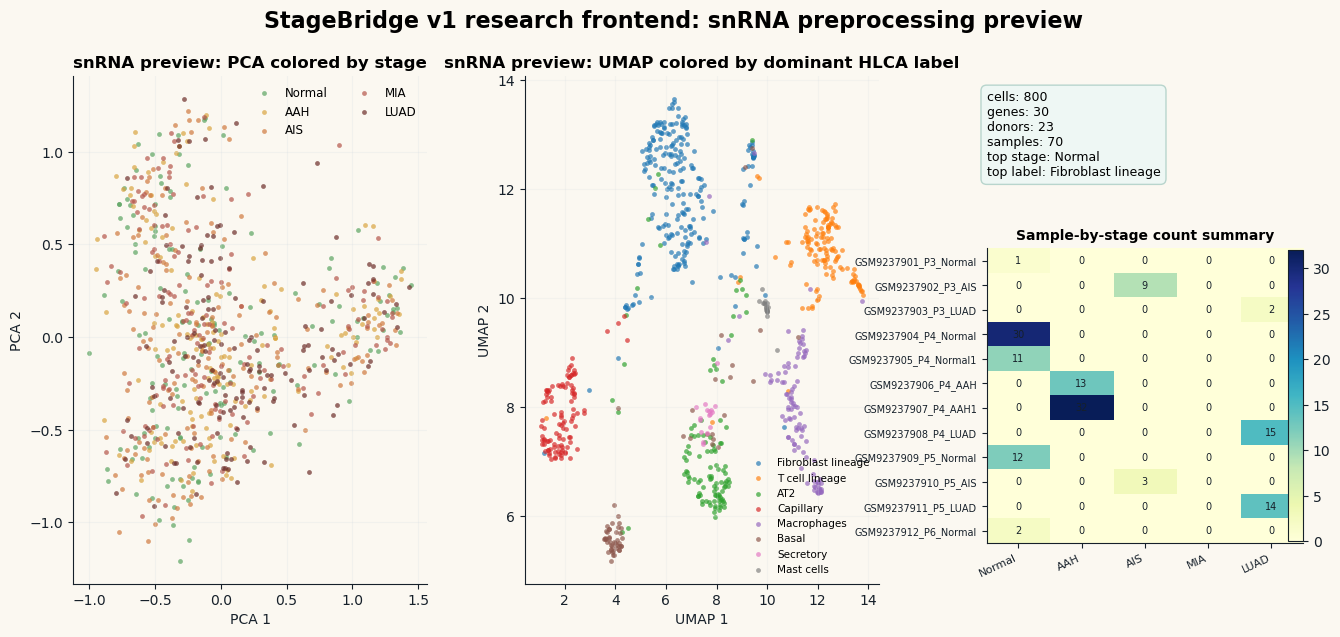

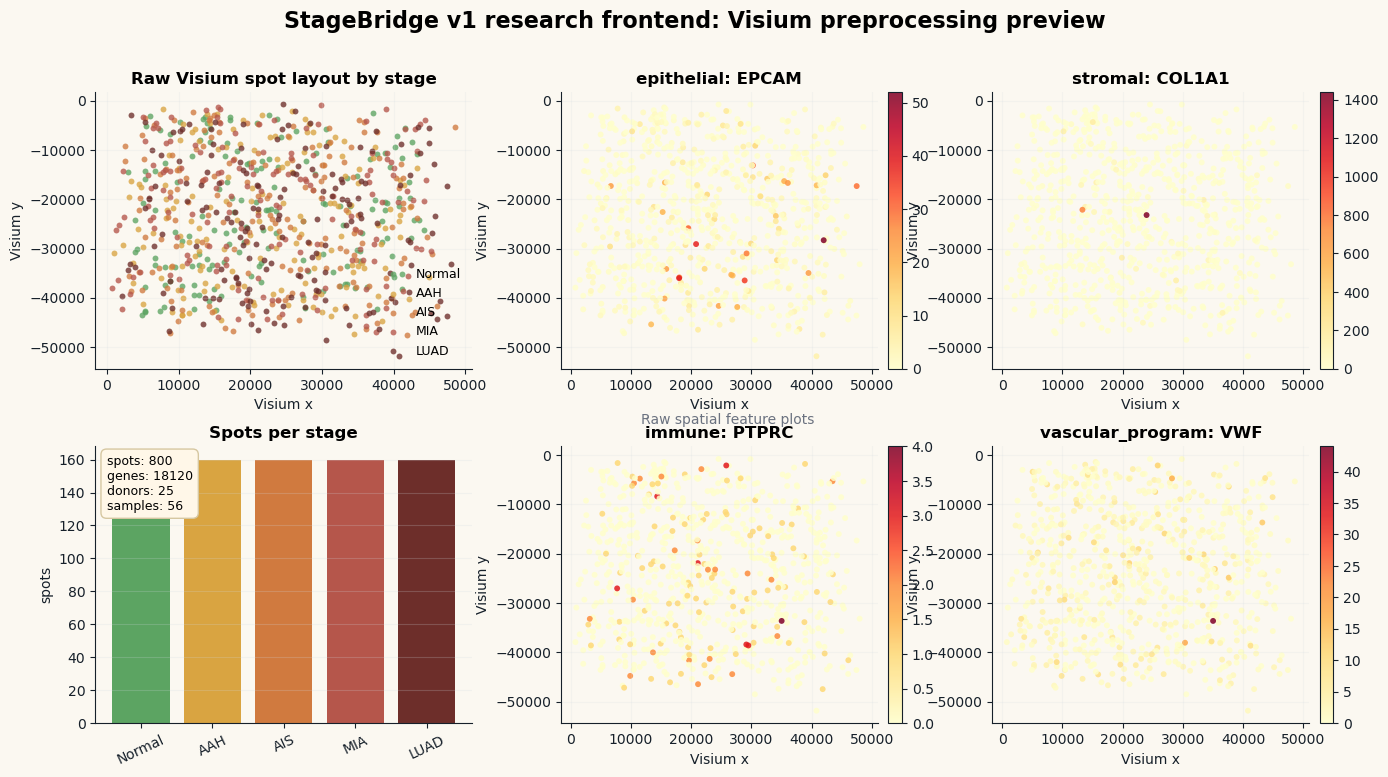

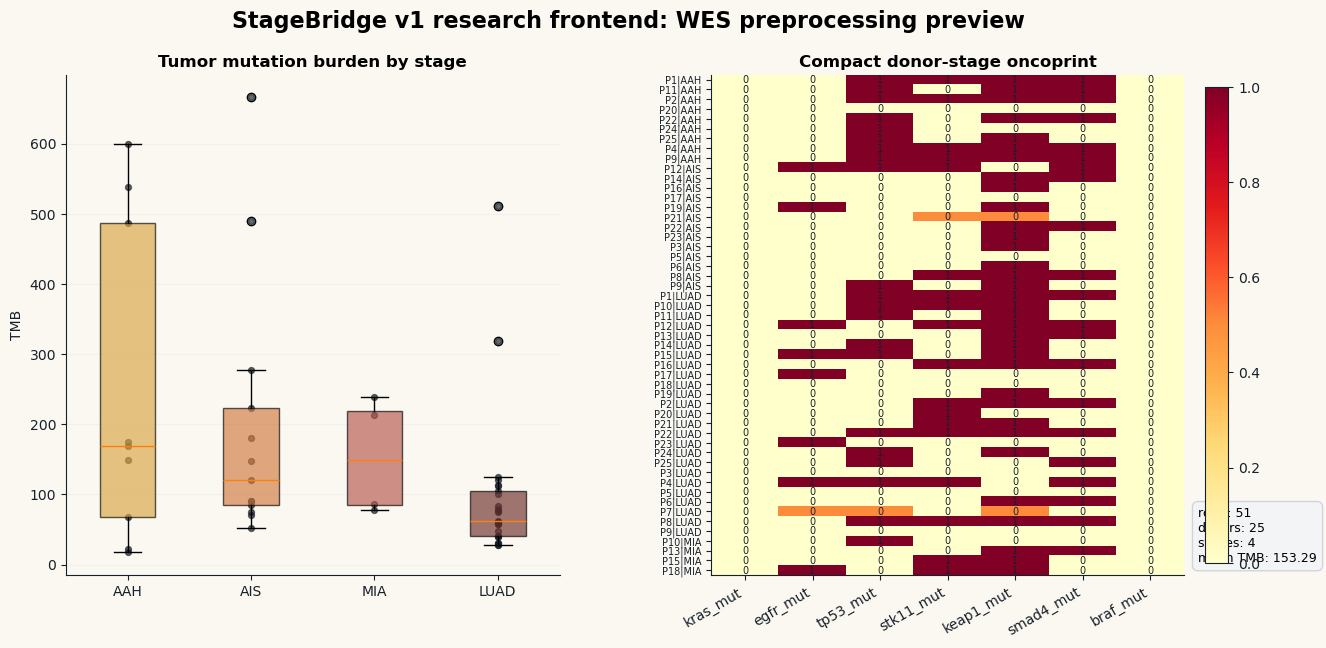

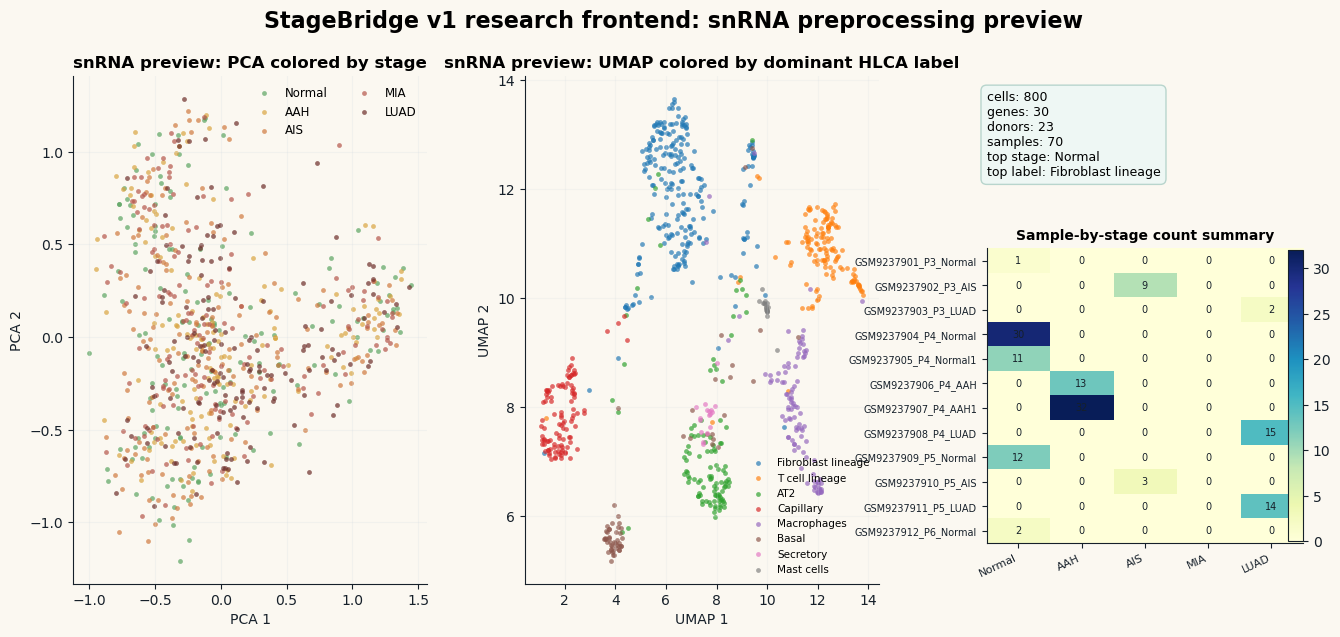

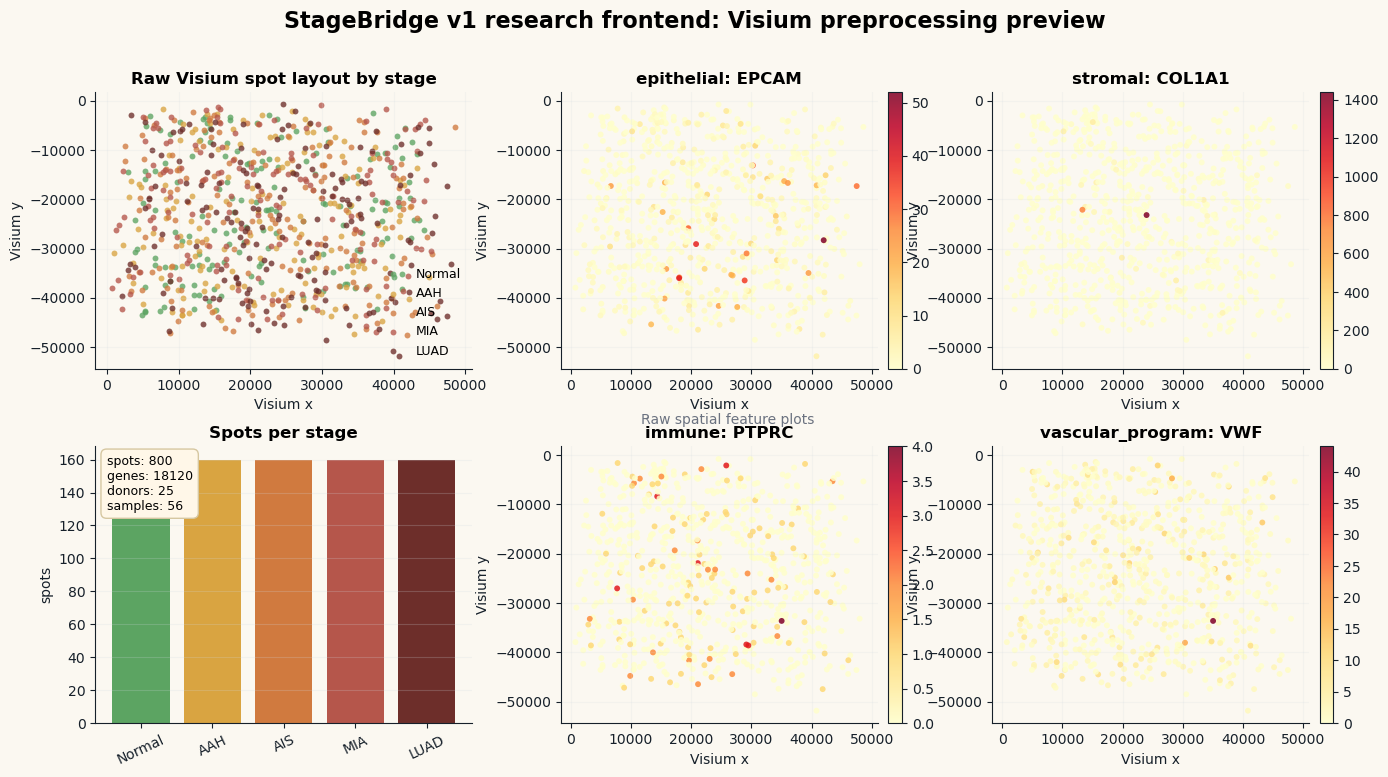

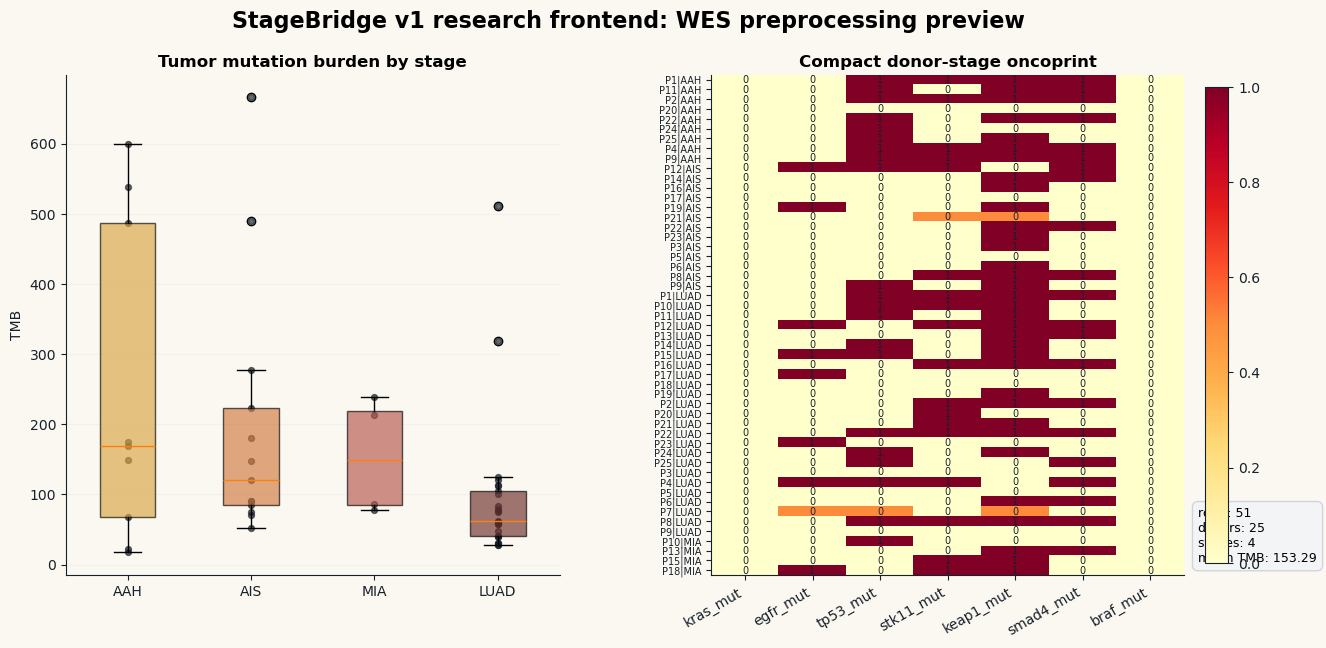

In [3]:
data_output = run_data_preprocessing_overview(
    cfg,
    max_cells_per_stage=160,
    max_spots_per_stage=160,
)

display(build_dataset_preprocessing_table(data_output))
display(plot_snrna_preprocessing_frontend(data_output))
display(plot_spatial_preprocessing_frontend(data_output))
display(plot_wes_preprocessing_frontend(data_output))


## Step 4. HLCA Reference Latent Mapping

**Purpose.** Run the active HLCA reference branch explicitly from the notebook so the latent backend is visible and traceable. This step is where the LUAD snRNA cohort is placed into the active reference latent representation.

**Input.** The configured reference backend in `stagebridge/reference/hlca_mapper.py`. At the moment the active backend may load the current HLCA latent artifact or fit the fallback PCA latent, depending on config.

**Output.** One reference payload containing the latent cohort, reference provenance, label transfer summary, and diagnostics payload used by the alignment gate.

**QC checks.** Confirm the backend name, provenance mode (`loaded` vs `fit`), latent shape, and source path. The next step turns those diagnostics into an explicit alignment gate.

**Relevant papers.** This step sits upstream of the spatial and transition layers and should be read together with the project’s atlas-alignment assumptions and the spatial-omics review material in [Optimal transport for single-cell and spatial omics: Primer](docs/papers/Optimal%20transport%20for%20single-cell%20and%20spatial%20omics-%20Primer.pdf).

**Next step.** Inspect the HLCA alignment statistics directly before using this latent as the default reference space for provider comparison.


In [4]:
reference_output = run_reference(cfg)
reference_payload = reference_output["reference"]
reference_gate = reference_payload["diagnostics"].get("alignment_gate", {})

pd.DataFrame(
    [
        {"field": "backend", "value": reference_payload.get("backend_name")},
        {"field": "provenance_mode", "value": reference_payload.get("provenance", {}).get("mode")},
        {"field": "latent_shape", "value": tuple(reference_payload.get("latent_shape", []))},
        {"field": "source_path", "value": reference_payload.get("source_path")},
        {"field": "alignment_gate", "value": reference_gate.get("status", "n/a")},
    ]
)


,field,value
0,backend,hlca
1,provenance_mode,loaded
2,latent_shape,"(1280, 30)"
3,source_path,/mnt/e/StageBridge_data/processed/anndata/snrn...
4,alignment_gate,weak_pass


## Step 5. HLCA Alignment and QC

**Purpose.** Audit the reference latent instead of treating it as a black box. This is the main honesty gate for the upstream representation.

**Input.** The reference payload from Step 4, including stage-separation diagnostics, donor-leakage diagnostics, gene-overlap diagnostics, local HLCA label agreement, and stage-vs-label alignment.

**Output.** A compact summary table, a richer evaluation table, transferred-label coverage, and one integrated figure showing latent structure, alignment confusion, centroid separation, and the gate outcome.

**QC checks.** The key questions are: is stage structure above chance, is donor leakage present but not dominant, how much gene overlap exists between the query cohort and HLCA, and are transferred labels locally coherent in the latent neighborhood? If this gate fails, any downstream provider selection is provisional at best.

**Relevant papers.** This step is upstream of the spatial/transformer story. If the reference branch is unstable, no later transformer result is trustworthy enough to center a paper around.

**Next step.** Rebuild Tangram, TACCO, and DestVI from the notebook and compare them under matched conditions.


,metric,value
0,latent_backend,hlca
1,provenance_mode,loaded
2,reference_source,/mnt/e/StageBridge_data/processed/anndata/snrn...
3,latent_n_cells,1280
4,latent_dim,30
5,stage_count,5
6,stage_probe_accuracy,0.346875
7,stage_probe_balanced_accuracy,0.346875
8,donor_leakage_accuracy,0.228125
9,donor_chance_accuracy,0.043478


,metric,value
0,stage_probe_accuracy,0.346875
1,stage_probe_balanced_accuracy,0.346875
2,stage_probe_chance,0.2
3,donor_leakage_accuracy,0.228125
4,donor_leakage_chance,0.043478
5,mean_stage_centroid_distance,0.737405
6,min_stage_centroid_distance,0.398738
7,label_coverage,1.0
8,gene_overlap_fraction,NaN
9,missing_gene_fraction,NaN


,label,count
0,Fibroblast lineage,373
1,T cell lineage,251
2,AT2,207
3,Capillary,150
4,Macrophages,138
5,Basal,86
6,Ciliated,26
7,Secretory,26
8,Mast cells,23


/home/ajbook/micromamba/envs/stagebridge/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


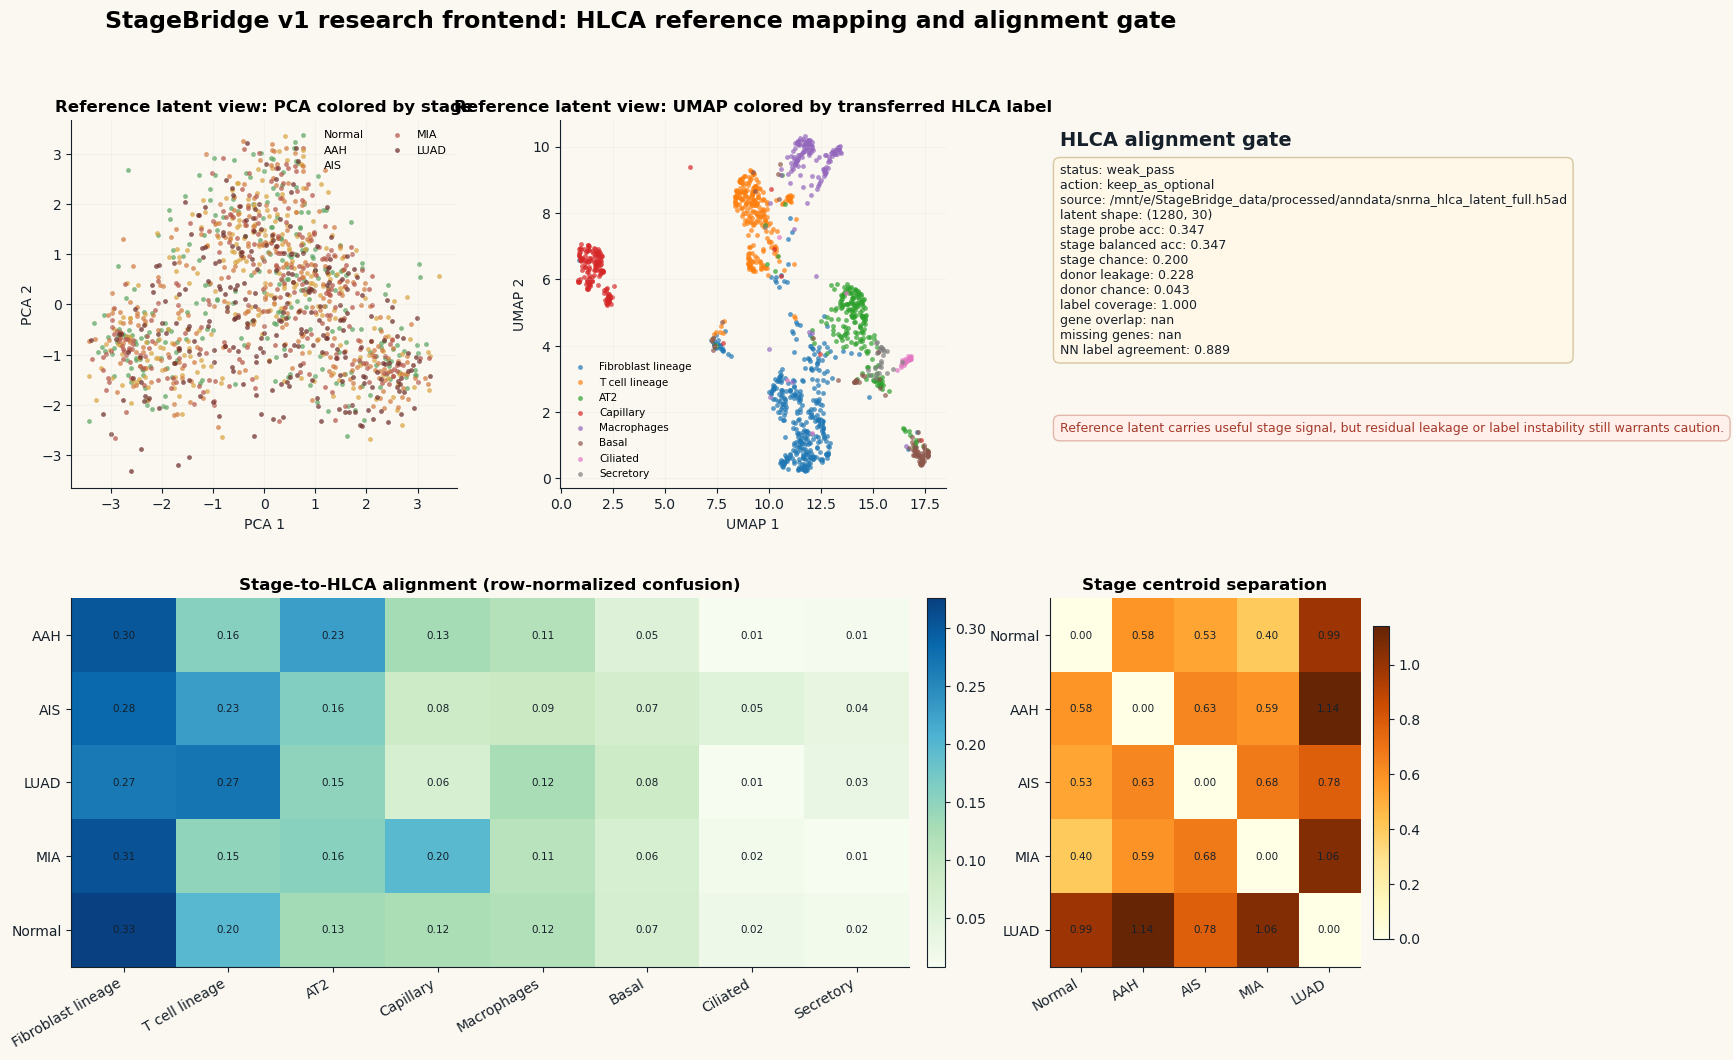

**HLCA gate status:** `weak_pass`  
**Recommended action:** `keep_as_optional`  
Reference latent carries useful stage signal, but residual leakage or label instability still warrants caution.

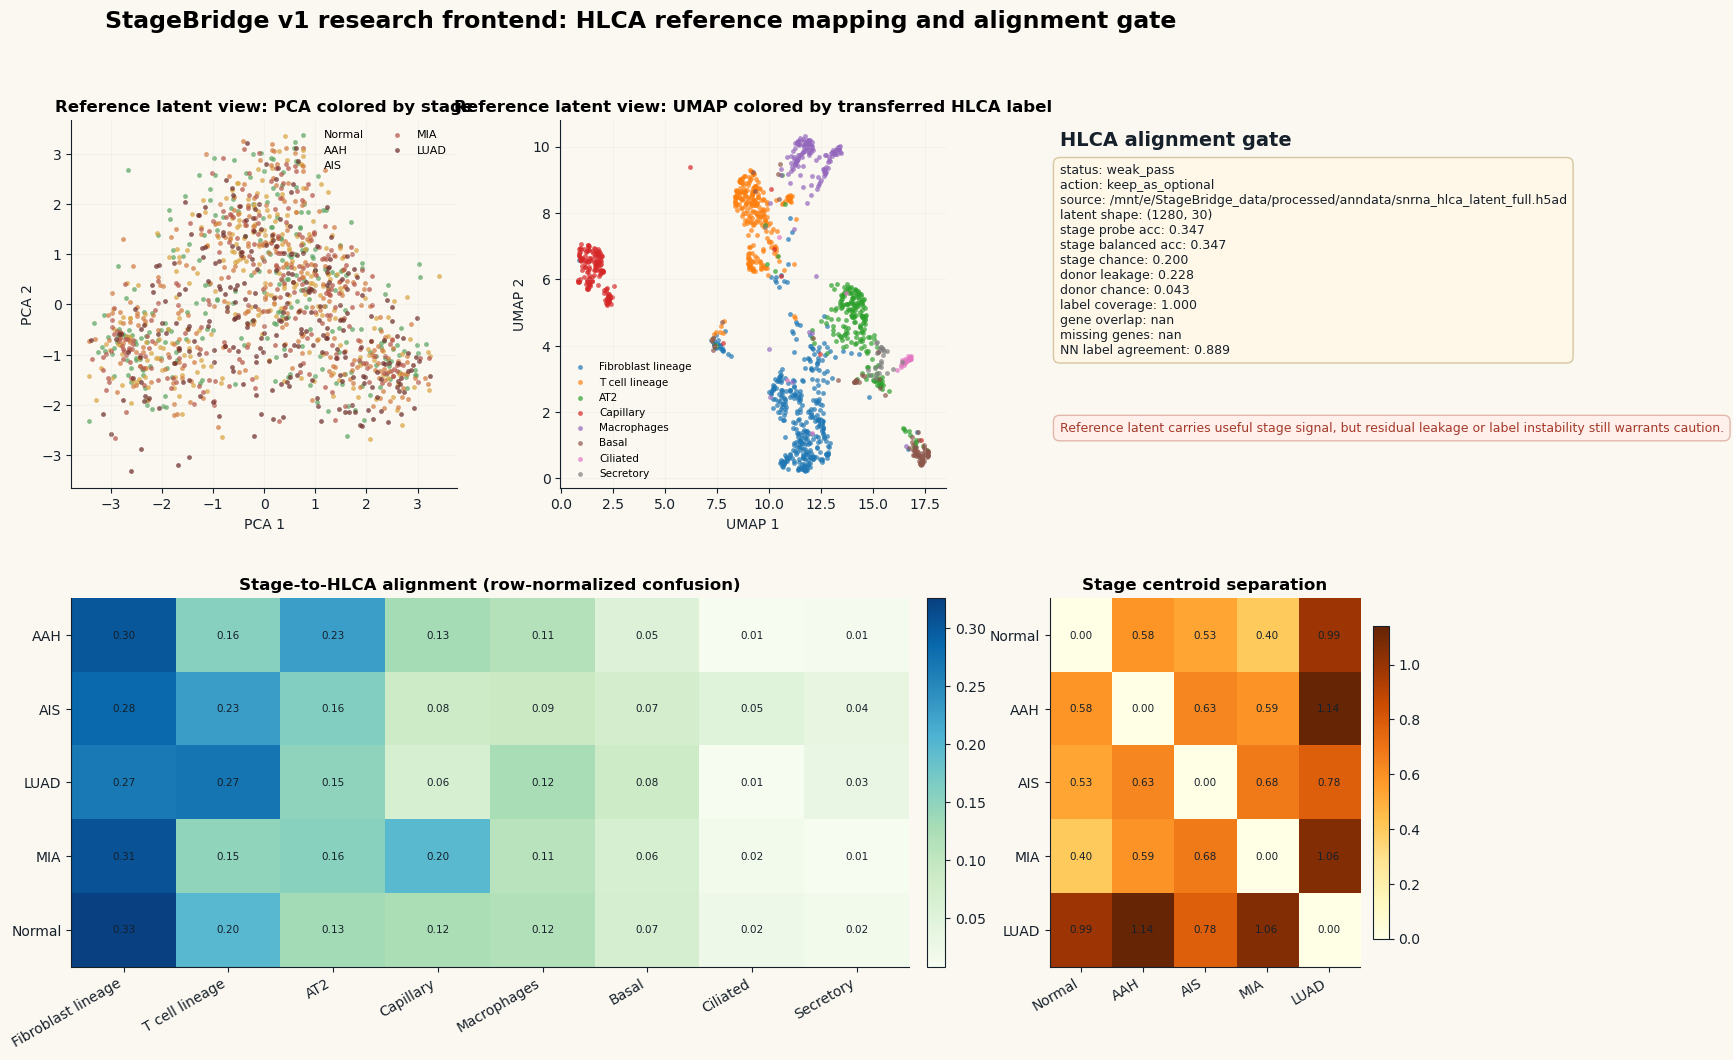

In [5]:
display(build_reference_summary_table(reference_output))
display(build_reference_evaluation_table(reference_output))
display(build_reference_label_table(reference_output))
display(plot_reference_frontend(reference_output))
display(Markdown(
    f"**HLCA gate status:** `{reference_gate.get('status', 'n/a')}`  \n**Recommended action:** `{reference_gate.get('recommended_action', 'n/a')}`  \n{reference_gate.get('interpretation', 'No interpretation available.')}"
))


## Step 6. Spatial Provider Rebuild and Comparison

**Purpose.** Rebuild the three named spatial providers from the notebook itself so their outputs are visible, comparable, and not silently pulled from stale precomputed artifacts.

**Input.** The HLCA-aligned reference output plus the current LUAD Visium slice. Providers are rebuilt with `Tangram`, `TACCO`, and `DestVI` through the active package entrypoints.

**Output.** A live provider status table, raw provider QC table, agreement table, a provider-comparison figure, side-by-side winner maps, and an abundance/entropy figure that shows how sharply or diffusely each provider is assigning spot-level compositions.

**QC checks.** Compare output coverage, row-sum behavior, assignment sharpness, entropy, and cross-provider agreement. Large disagreement is a reason to slow down, not a reason to pick the most visually dramatic provider.

**Relevant papers.** [Tangram](docs/papers/Deep%20learning%20and%20alignment%20of%20spatially%20resolved%20single-cell%20transcriptomes%20with%20Tangram.pdf), [TACCO](docs/papers/TACCO%20unifies%20annotation%20transfer%20and%20decomposition%20of%20cell%20identities%20for%20single-cell%20and%20spatial%20omics.pdf), and [DestVI](docs/papers/DestVI%20identifies%20continuums%20of%20cell%20types%20in%20spatial%20transcriptomics%20data.pdf) motivate the three provider surfaces, but StageBridge still needs an objective winner rather than a paper-name preference.

**Next step.** Run the hybrid provider benchmark that combines mapping QC, downstream performance, and biological stability, then choose a winner or declare the choice inconclusive.


Spatial providers:   0%|          | 0/3 [00:00<?, ?run/s]

... storing 'donor_id' as categorical
... storing 'patient_id' as categorical
... storing 'sample_id' as categorical
... storing 'stage' as categorical
... storing 'hlca_label' as categorical
... storing 'spot_id' as categorical
... storing 'barcode' as categorical
... storing 'donor_id' as categorical
... storing 'patient_id' as categorical
... storing 'stage' as categorical
... storing 'sample_id' as categorical


Tangram: aggregate HLCA profiles:   0%|          | 0/2 [00:00<?, ?chunk/s]

2026-03-09 01:22:29 | INFO     | root | 2961 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
2026-03-09 01:22:29 | INFO     | root | 2961 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
2026-03-09 01:22:29 | INFO     | root | uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
2026-03-09 01:22:29 | INFO     | root | rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.
2026-03-09 01:22:29 | INFO     | root | Allocate tensors for mapping.
2026-03-09 01:22:29 | INFO     | root | Begin training with 2961 genes and rna_count_based density_prior in cells mode...
2026-03-09 01:22:30 | INFO     | root | Printing scores every 100 epochs.
Score: 0.246, KL reg: 0.613
Score: 0.484, KL reg: 0.001
Score: 0.486, KL reg: 0.001
Score: 0.486, KL reg: 0.001
Score: 0.487, KL reg: 0.001
2026-03-09 01:22:31 | INF

INFO: Seed set to 42


...

INFO: `Trainer.fit` stopped: `max_epochs=2` reached.


2026-03-09 01:24:16 | INFO     | lightning.pytorch.utilities.rank_zero | `Trainer.fit` stopped: `max_epochs=2` reached.


,method,status,provider_version,execution_mode,n_spots,n_features,source_path,notes
0,tangram,complete,1.0.4,force_rebuild,640,9,/home/ajbook/projects/StageBridge/outputs/scra...,Tangram mapping rebuilt from raw snRNA and spa...
1,tacco,complete,0.4.0.post1,force_rebuild,640,9,/home/ajbook/projects/StageBridge/outputs/scra...,TACCO mapping rebuilt from raw snRNA and spati...
2,destvi,complete,1.4.2,force_rebuild,640,9,/home/ajbook/projects/StageBridge/outputs/scra...,DestVI mapping rebuilt from raw snRNA and spat...


,method,status,execution_mode,n_spots,n_features,provider_version,mean_row_sum,std_row_sum,rows_close_to_one_frac,mean_max_assignment,mean_normalized_entropy,winner_diversity,dominant_feature,qc_heuristic_score
0,tacco,complete,force_rebuild,640,9,0.4.0.post1,1.000000,1.928535e-08,1.0,0.541157,0.490644,7,Capillary,0.741276
1,destvi,complete,force_rebuild,640,9,1.4.2,1.000000,4.580744e-08,1.0,0.155602,0.987675,8,Fibroblast lineage,0.506926
2,tangram,complete,force_rebuild,640,9,1.0.4,0.014062,1.672119e-02,0.0,0.344311,0.797568,9,Capillary,0.167323


,left_method,right_method,n_shared_spots,n_shared_features,winner_agreement,mean_abs_diff,mean_cosine_similarity
0,tangram,tacco,640,9,0.226562,0.141957,0.463227
1,tangram,destvi,640,9,0.140625,0.087383,0.705530
2,tacco,destvi,640,9,0.085938,0.139293,0.510564


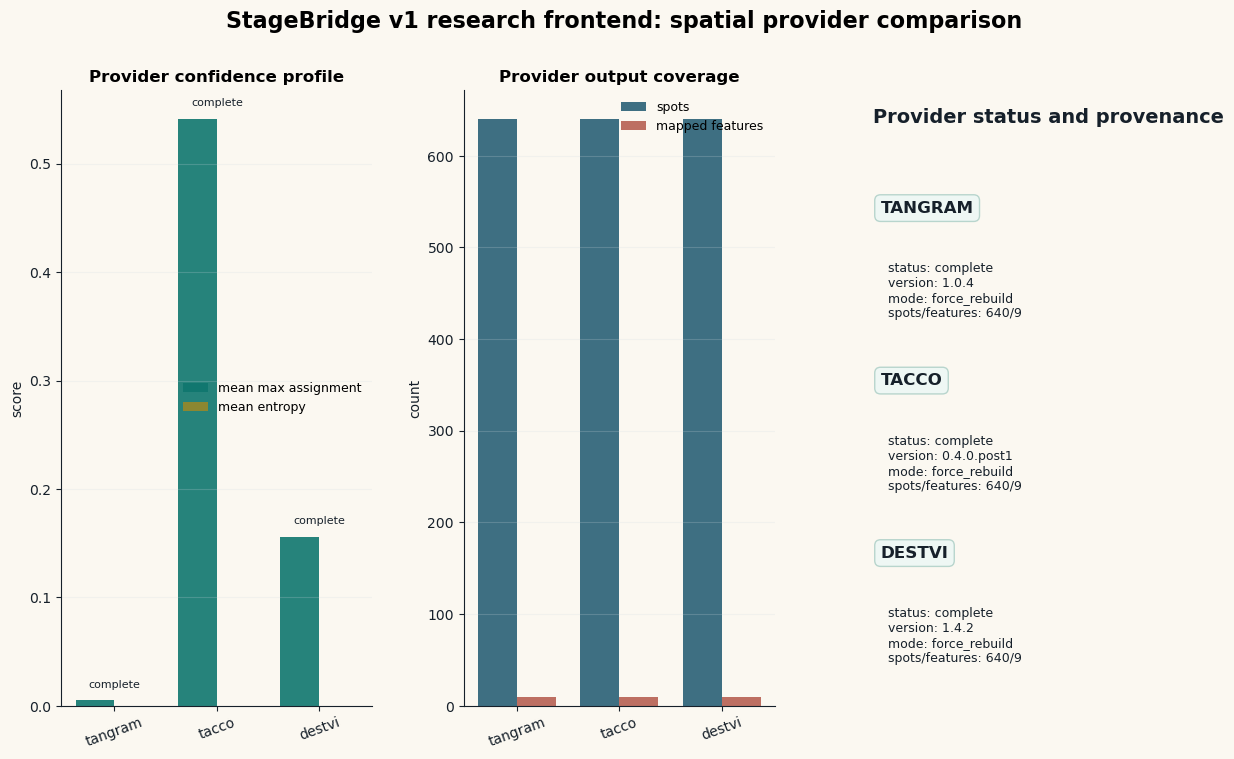

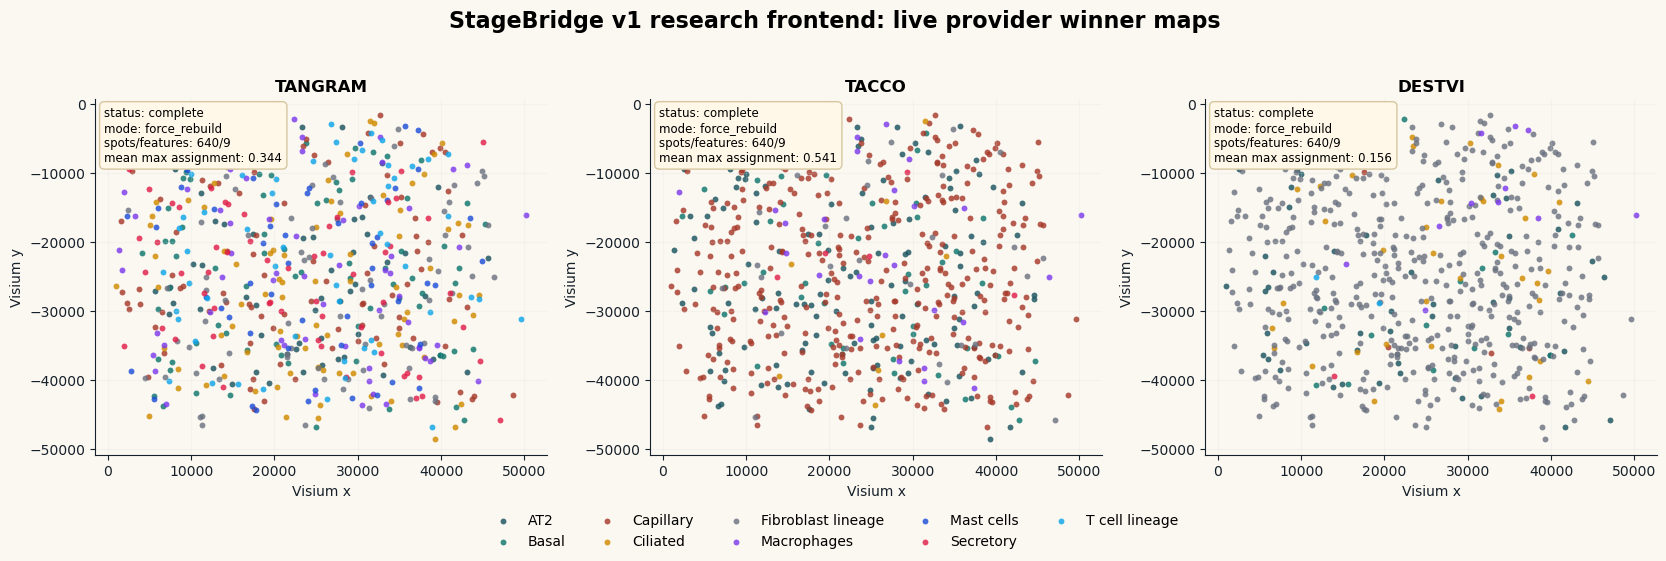

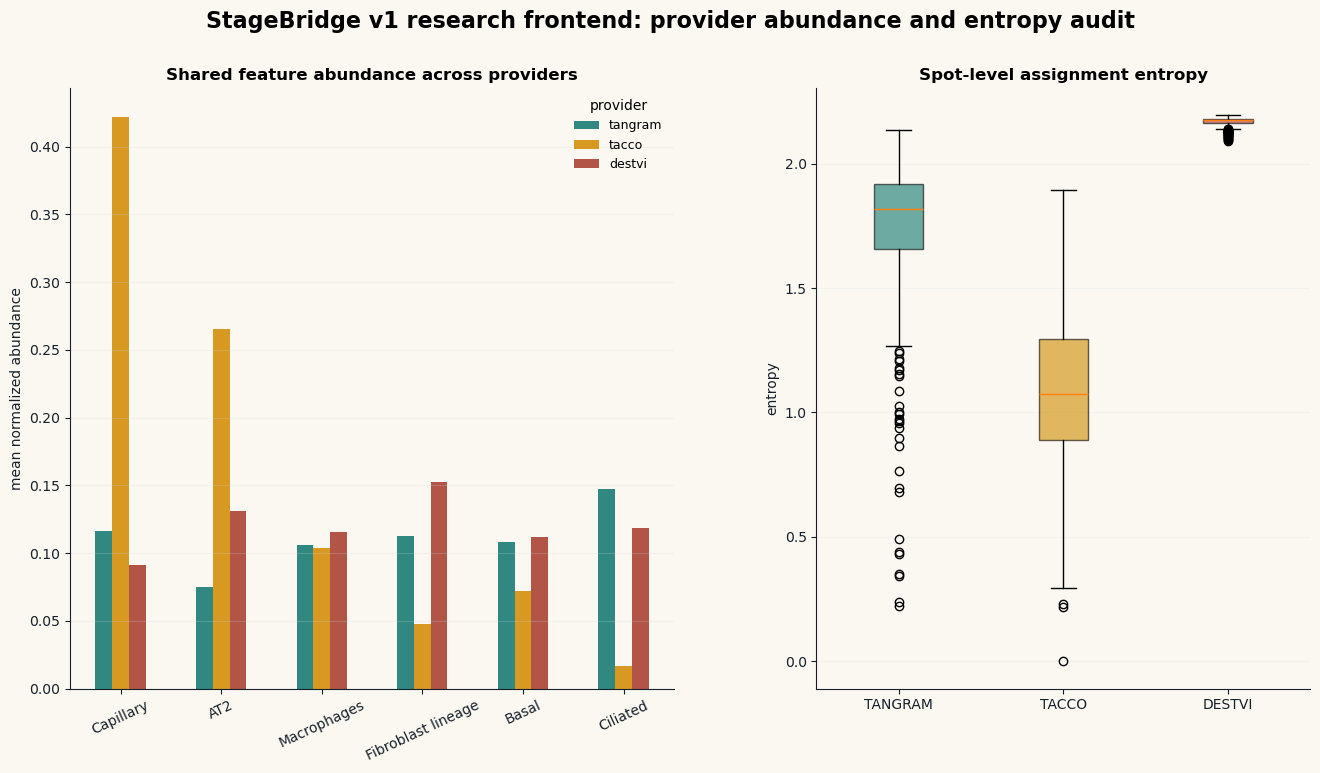

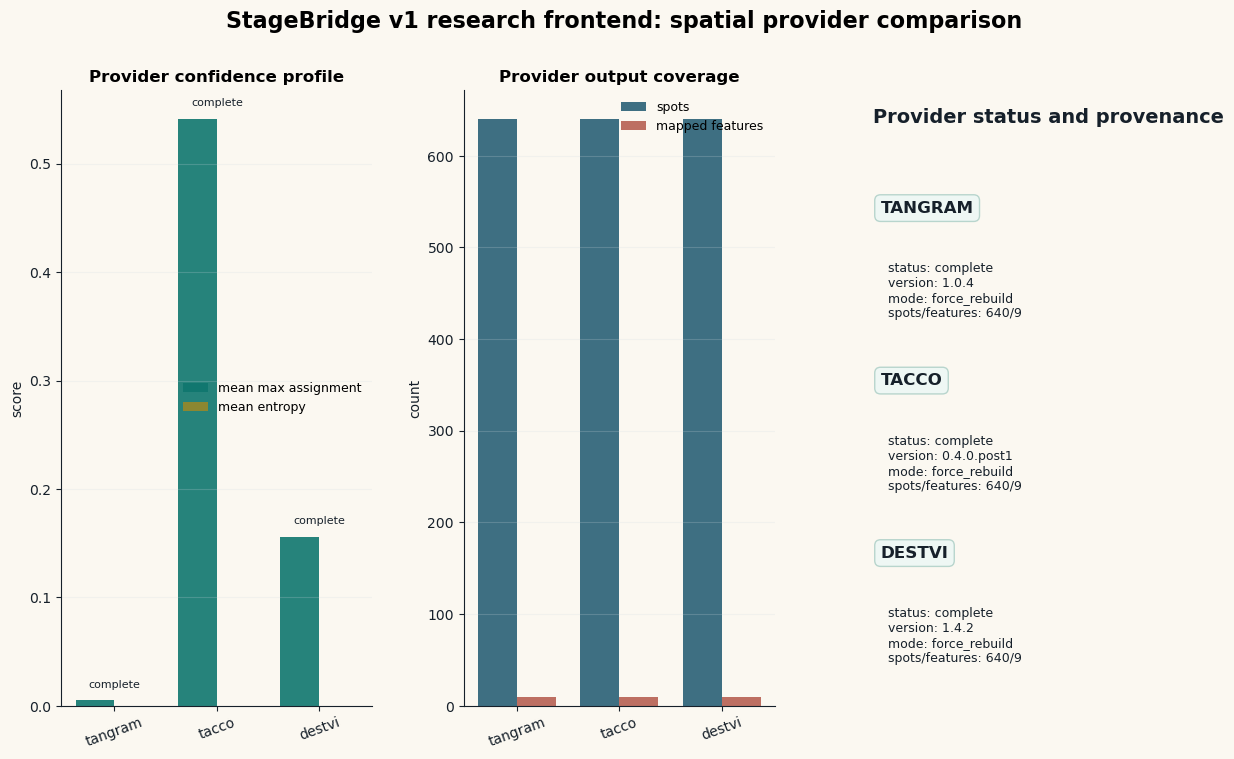

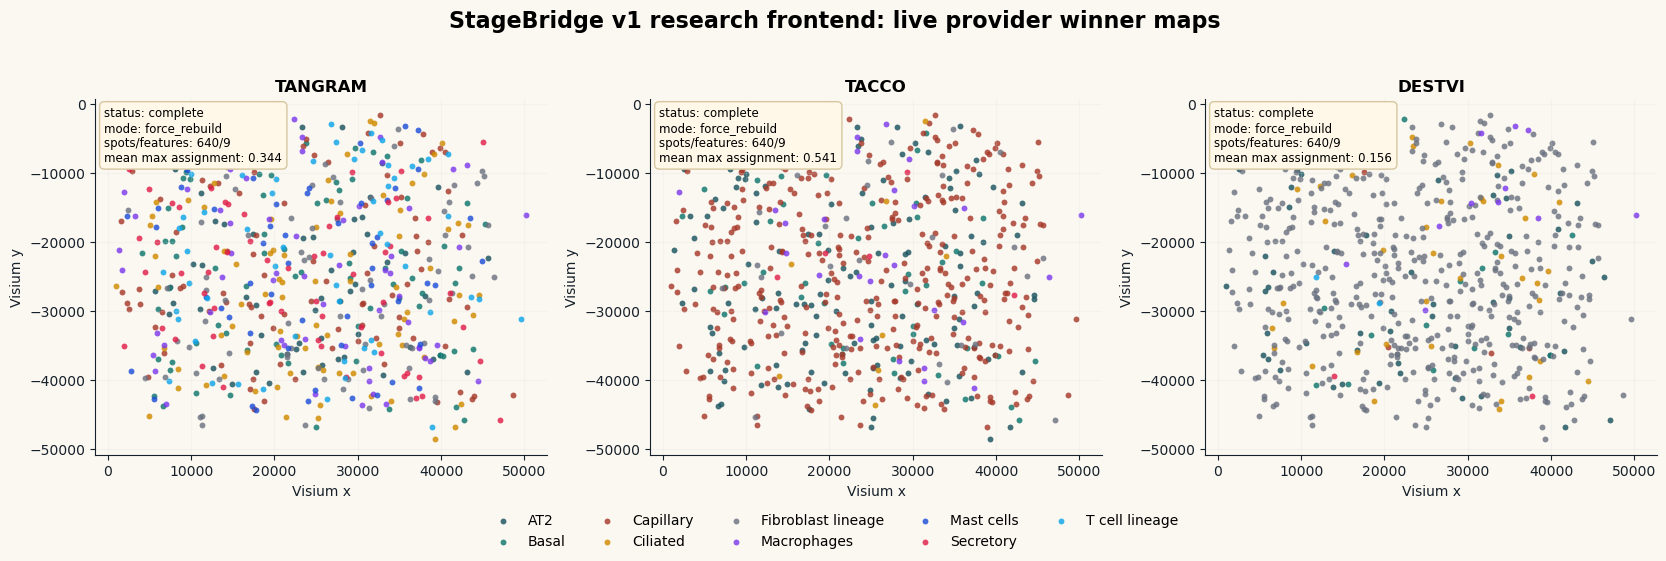

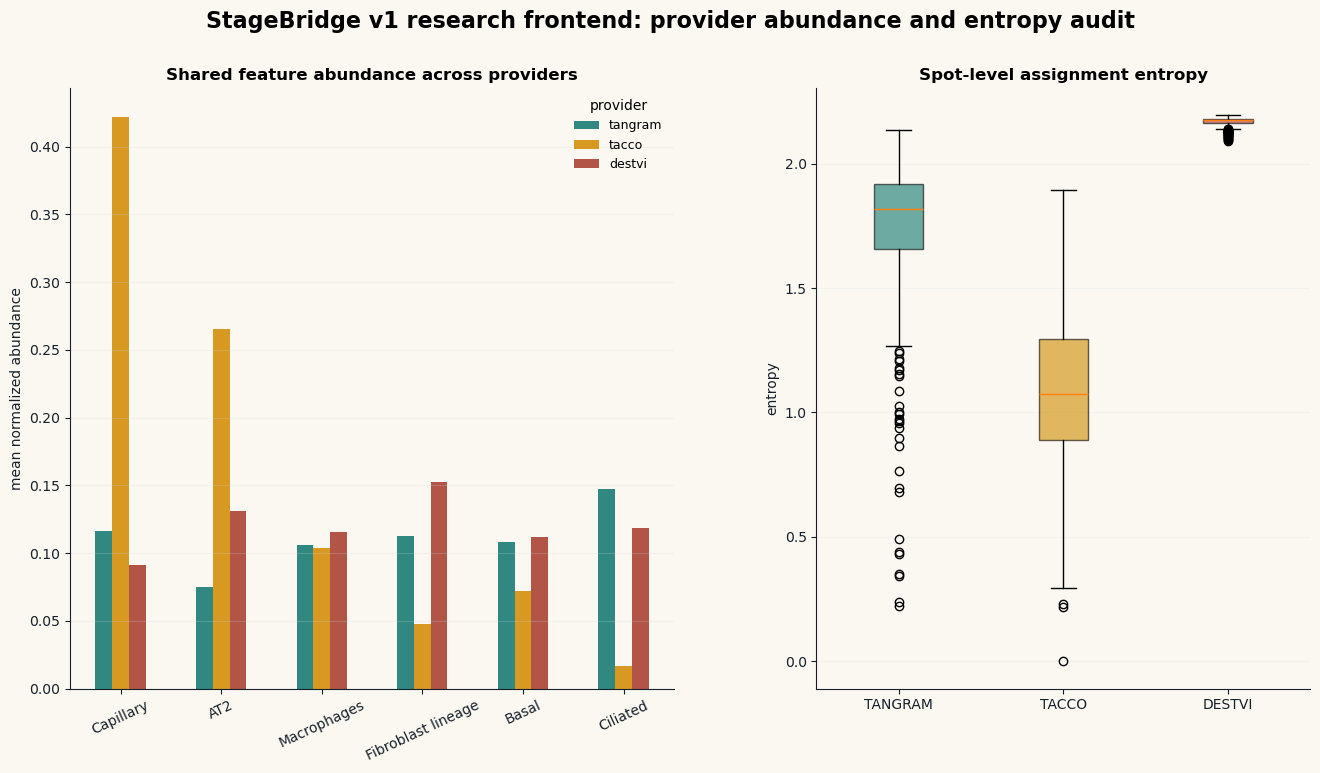

In [6]:
provider_outputs = run_spatial_provider_ladder(
    cfg,
    methods=["tangram", "tacco", "destvi"],
    reference_output=reference_output,
    execution_mode="force_rebuild",
    use_tqdm=True,
)

display(build_spatial_provider_table(provider_outputs))
display(build_spatial_provider_metric_table(provider_outputs))
display(build_spatial_provider_agreement_table(provider_outputs))
display(plot_spatial_provider_comparison_frontend(provider_outputs))
display(plot_spatial_provider_maps_frontend(provider_outputs))
display(plot_spatial_provider_abundance_frontend(provider_outputs))


## Step 7. Provider Winner Selection

**Purpose.** Convert the raw provider comparison into a reproducible selection rule. StageBridge should not pick a spatial provider by taste or by whichever map looks nicest.

**Input.** Matched provider rebuilds plus a hybrid benchmark that scores each provider using (1) mapping QC, (2) downstream performance on `pooled` and `deep_sets` across `AAH -> AIS` and `AIS -> MIA`, and (3) biological stability across seeds.

**Output.** A benchmark table, a benchmark figure, a machine-readable `selected_provider`, and a selection status that can still be `inconclusive` if the winner is not decisive.

**QC checks.** If the top provider does not separate cleanly from the runner-up, keep the comparison explicit and mark the downstream default as provisional. Do not silently lock in a winner on a weak margin.

**Next step.** Use the selected provider, or the current strongest provisional provider, to build the typed spot-token representation that feeds the context branch.


Provider benchmark seeds:   0%|          | 0/3 [00:00<?, ?run/s]

Tangram: aggregate HLCA profiles:   0%|          | 0/2 [00:00<?, ?chunk/s]

2026-03-09 01:27:21 | INFO     | root | 2959 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
2026-03-09 01:27:21 | INFO     | root | 2959 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
2026-03-09 01:27:21 | INFO     | root | uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
2026-03-09 01:27:21 | INFO     | root | rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.
2026-03-09 01:27:21 | INFO     | root | Allocate tensors for mapping.
2026-03-09 01:27:21 | INFO     | root | Begin training with 2959 genes and rna_count_based density_prior in cells mode...
2026-03-09 01:27:21 | INFO     | root | Printing scores every 100 epochs.
Score: 0.224, KL reg: 0.755
Score: 0.512, KL reg: 0.001
Score: 0.515, KL reg: 0.001
Score: 0.515, KL reg: 0.001
Score: 0.515, KL reg: 0.001
2026-03-09 01:27:23 | INF

INFO: Seed set to 7


2026-03-09 01:31:23 | INFO     | lightning.fabric.utilities.seed | Seed set to 7


...

Training:   0%|          | 0/2 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=2` reached.


2026-03-09 01:44:17 | INFO     | lightning.pytorch.utilities.rank_zero | `Trainer.fit` stopped: `max_epochs=2` reached.


,method,mean_row_sum,rows_close_to_one_frac,mean_max_assignment,mean_normalized_entropy,complete_fraction,row_sum_deviation,mapping_rank,sinkhorn_mean,sinkhorn_std,calibration_mean,calibration_std,performance_rank,dominant_pair_consistency,edge_interpretation_distinctiveness,winner_agreement_mean,cosine_similarity_mean,stability_rank,hybrid_rank_score
0,tangram,0.014062,0.0,0.351503,0.789368,1.0,0.985938,1.75,17.534716,2.095690,4.194391,0.324094,1.5,0.500000,1.0,0.209375,0.591646,2.000000,1.687500
1,tacco,1.000000,1.0,0.543280,0.493484,1.0,0.000000,1.00,17.581179,2.144877,4.214870,0.322537,2.5,0.833333,1.0,0.320052,0.534276,1.000000,1.750000
2,destvi,1.000000,1.0,0.157433,0.989216,1.0,0.000000,2.00,17.643675,2.135501,4.176976,0.314325,2.0,0.500000,1.0,0.289323,0.652202,1.666667,1.916667


# Spatial Provider Benchmark

- Selected provider: tangram
- Selection status: inconclusive
- Recommended action: keep_as_optional
- Winner margin: 0.0625
- Interpretation: tangram ranked first, but the margin to the runner-up (0.062) is too small to call the provider winner decisive.

## tangram
- Hybrid score: 1.6875
- Mapping rank: 1.75
- Performance rank: 1.5
- Stability rank: 2.0
- Sinkhorn mean: 17.5347162882487
- Calibration mean: 4.194390694300334
- Mean max assignment: 0.3515033423900604
- Mean normalized entropy: 0.789368324838049

## tacco
- Hybrid score: 1.75
- Mapping rank: 1.0
- Performance rank: 2.5
- Stability rank: 1.0
- Sinkhorn mean: 17.58117945988973
- Calibration mean: 4.214870413144429
- Mean max assignment: 0.5432803432146708
- Mean normalized entropy: 0.49348368659713016

## destvi
- Hybrid score: 1.9166666666666667
- Mapping rank: 2.0
- Performance rank: 2.0
- Stability rank: 1.6666666666666667
- Sinkhorn mean: 17.643675088882446
- Calibration mean: 4.176975687344869
- Mean max assignment: 0.1574334353208542
- Mean normalized entropy: 0.9892159271055507


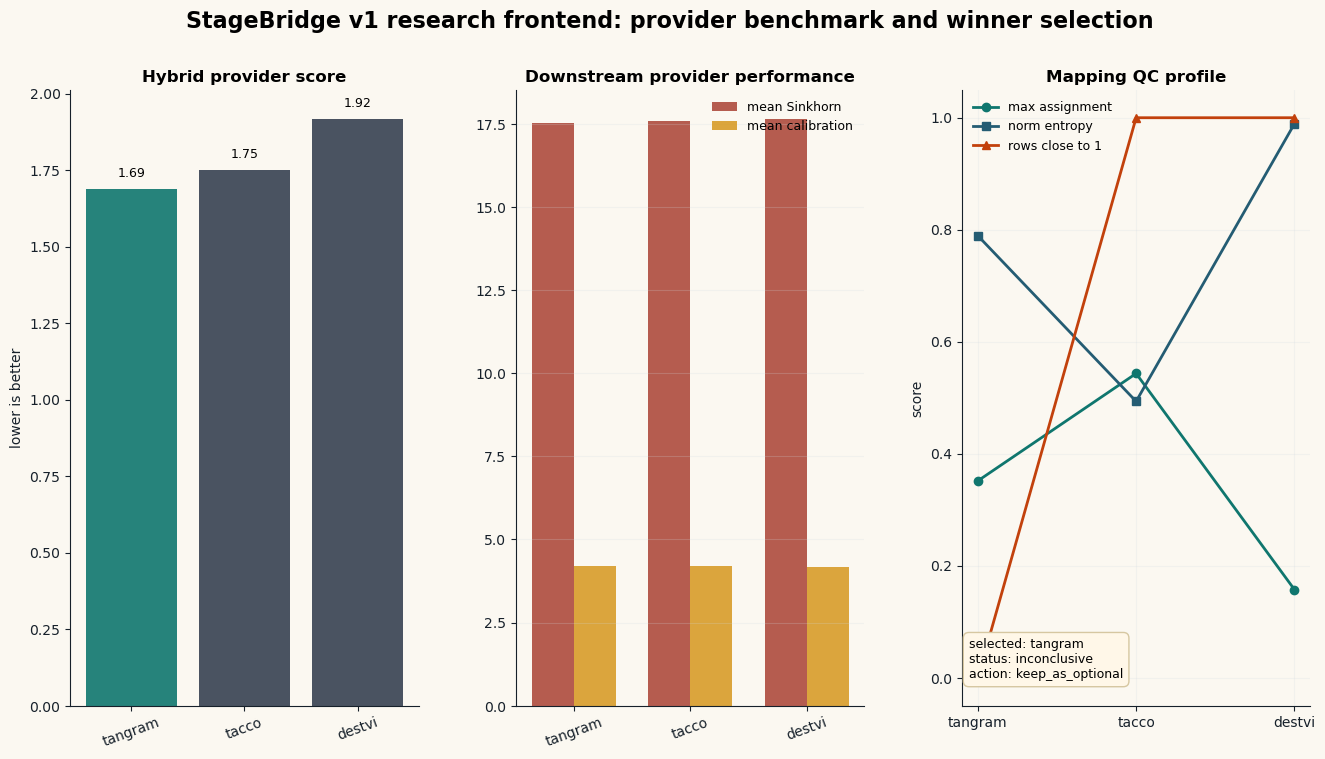

,field,value
0,selected_provider,tangram
1,selection_status,inconclusive
2,selection_reason,"tangram ranked first, but the margin to the ru..."


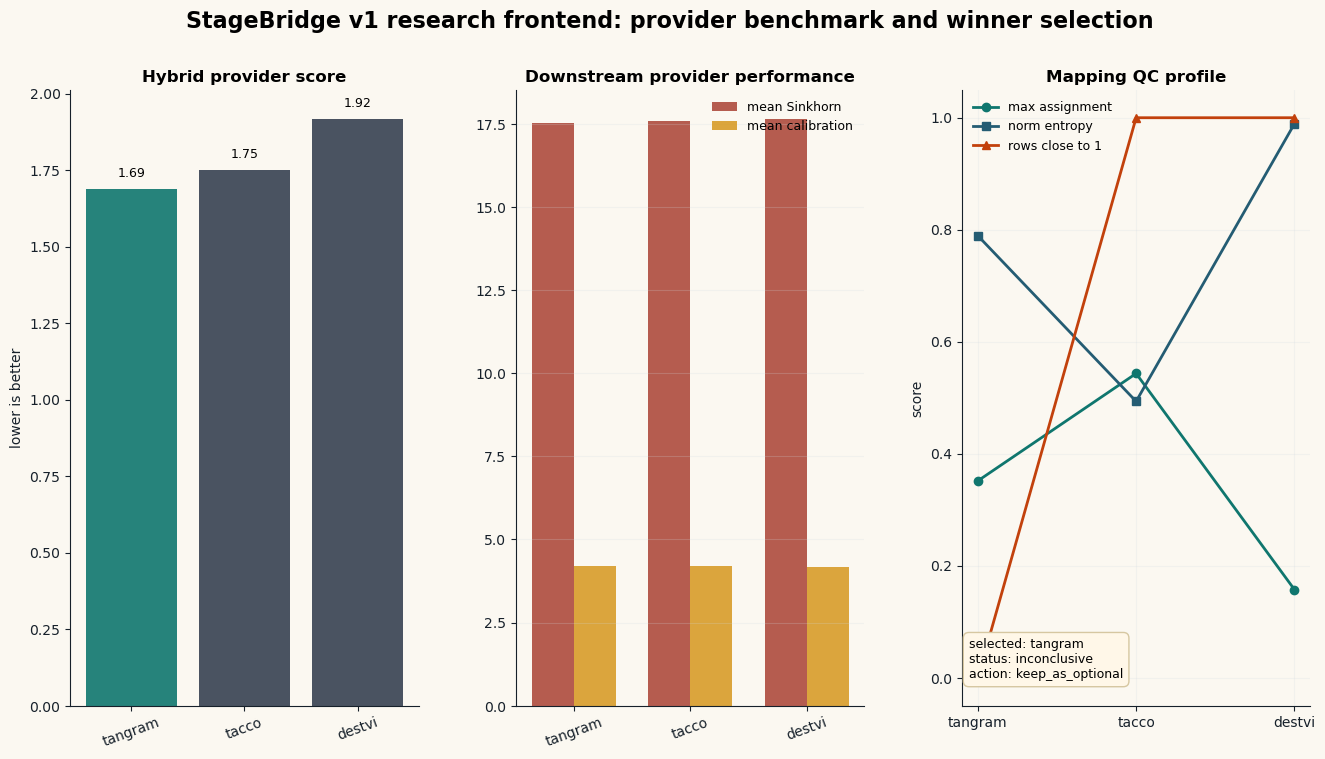

In [7]:
benchmark_output = run_provider_benchmark(
    cfg,
    methods=["tangram", "tacco", "destvi"],
    modes=["pooled", "deep_sets"],
    edges=["AAH->AIS", "AIS->MIA"],
    seeds=[7, 13, 29],
    execution_mode="force_rebuild",
    use_tqdm=True,
    reference_output=reference_output,
)

display(build_provider_benchmark_table(benchmark_output))
display(Markdown(benchmark_output["benchmark_md"]))
display(plot_provider_benchmark_frontend(benchmark_output))

cfg_selected = apply_selected_provider(cfg, benchmark_output)
cfg_selected.spatial_mapping.execution_mode = "rebuild_cached"
selected_provider = cfg_selected.spatial_mapping.method
selected_summary = pd.DataFrame(
    [
        {"field": "selected_provider", "value": selected_provider},
        {"field": "selection_status", "value": cfg_selected.spatial_mapping.selection_status},
        {"field": "selection_reason", "value": cfg_selected.spatial_mapping.selection_reason},
    ]
)
display(selected_summary)


## Step 8. Typed Token Construction

**Purpose.** Build the active typed niche representation from the selected spatial provider. Each Visium spot becomes a typed biological set rather than an anonymous vector.

**Input.** The selected or provisional provider output from Step 7, plus the token builder in `stagebridge/context_model/token_builder.py`.

**Output.** The active spatial mapping summary for the chosen provider and a typed token object that groups epithelial, stromal, immune, and vascular/program signals into a deterministic schema.

**QC checks.** Confirm that the selected provider is actually the one being used downstream, that the spatial mapping summary looks sane, and that the typed token branch is built from the selected provider rather than an old default.

**Relevant papers.** This is where the spatial provider becomes StageBridge’s typed niche representation; it is the bridge from spatial deconvolution into the set-based context models described in [Deep Sets](docs/papers/Deep%20Sets.pdf) and [Set Transformer](docs/papers/Set%20Transformer%20A%20Framework%20for%20Attention-based%20Permutation-Invariant%20Neural%20Networks.pdf).

**Next step.** Encode those typed tokens with the currently selected context mode and inspect the transformer-relevant diagnostics before fitting the transition model.


Tangram: aggregate HLCA profiles:   0%|          | 0/2 [00:00<?, ?chunk/s]

2026-03-09 01:46:54 | INFO     | root | 2961 training genes are saved in `uns``training_genes` of both single cell and spatial Anndatas.
2026-03-09 01:46:54 | INFO     | root | 2961 overlapped genes are saved in `uns``overlap_genes` of both single cell and spatial Anndatas.
2026-03-09 01:46:54 | INFO     | root | uniform based density prior is calculated and saved in `obs``uniform_density` of the spatial Anndata.
2026-03-09 01:46:54 | INFO     | root | rna count based density prior is calculated and saved in `obs``rna_count_based_density` of the spatial Anndata.
2026-03-09 01:46:54 | INFO     | root | Allocate tensors for mapping.
2026-03-09 01:46:54 | INFO     | root | Begin training with 2961 genes and rna_count_based density_prior in cells mode...
2026-03-09 01:46:54 | INFO     | root | Printing scores every 100 epochs.
Score: 0.248, KL reg: 0.630
Score: 0.484, KL reg: 0.001
Score: 0.486, KL reg: 0.001
Score: 0.487, KL reg: 0.001
Score: 0.487, KL reg: 0.001
2026-03-09 01:46:56 | INF

,metric,value
0,method,tangram
1,status,complete
2,n_spots,640
3,n_features,9
4,mean_row_sum,0.014062
5,mean_max_assignment,0.004984
6,source_path,/home/ajbook/projects/StageBridge/outputs/scra...


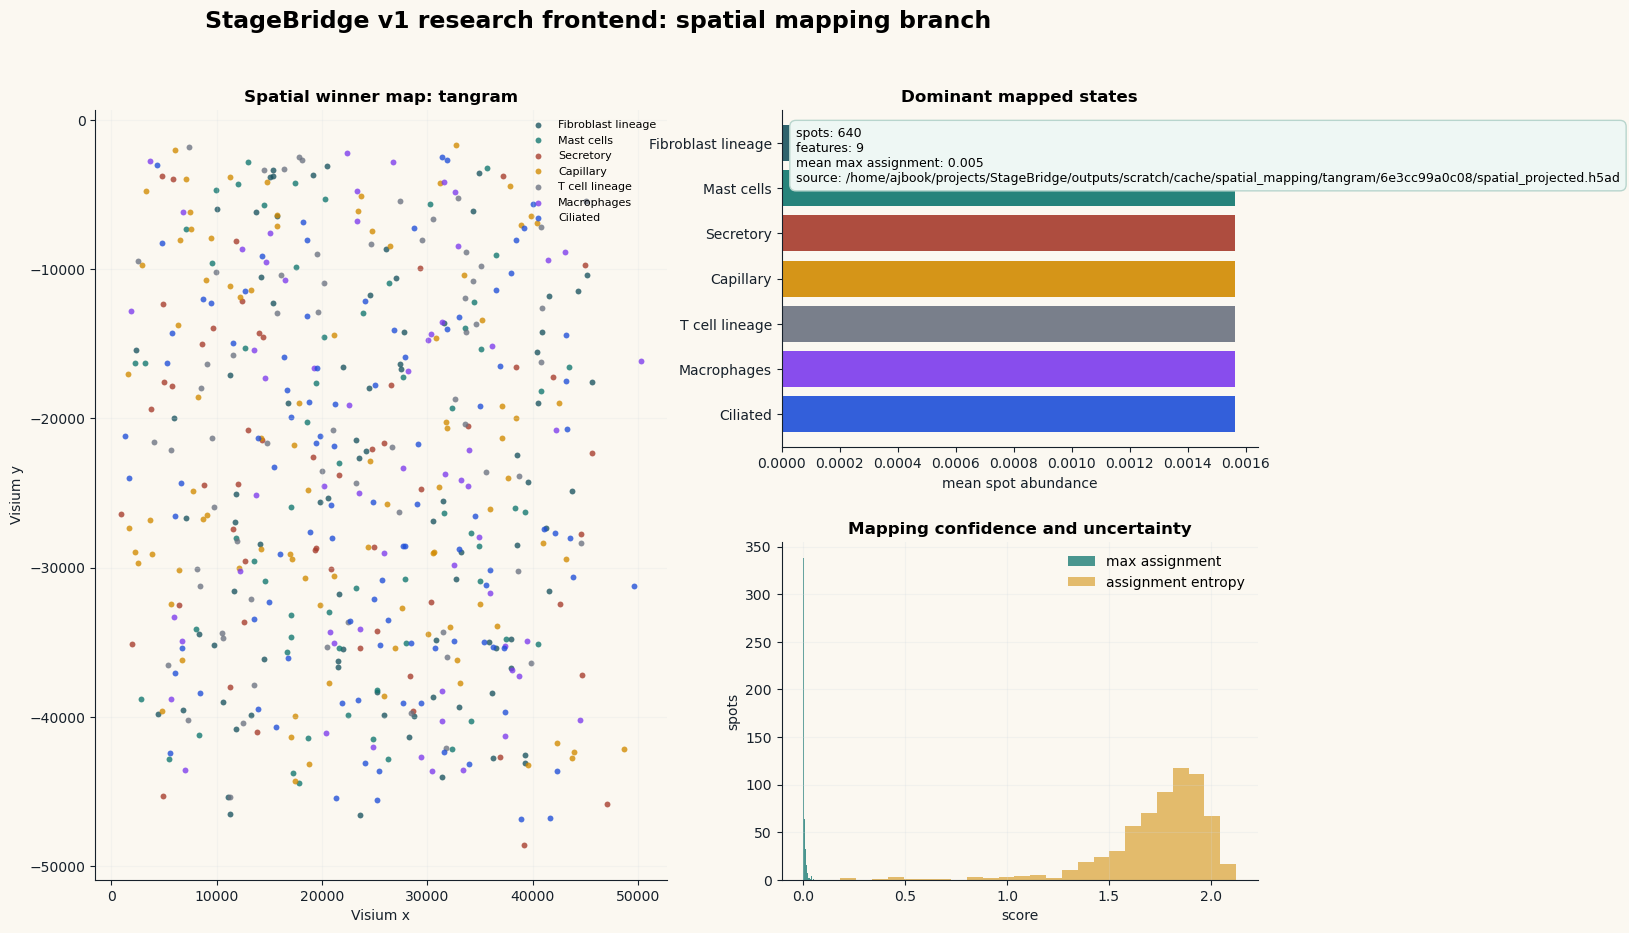

,field,value
0,n_tokens,640
1,token_dim,4
2,typed_feature_names,"[epithelial, stromal, immune, vascular_program]"
3,stage_counts,"{'AAH': 128, 'AIS': 128, 'LUAD': 128, 'MIA': 1..."
4,mean_token_confidence,0.2064
5,missing_token_fraction,0.0
6,token_group_means,"{'epithelial': 0.44853001832962036, 'stromal':..."


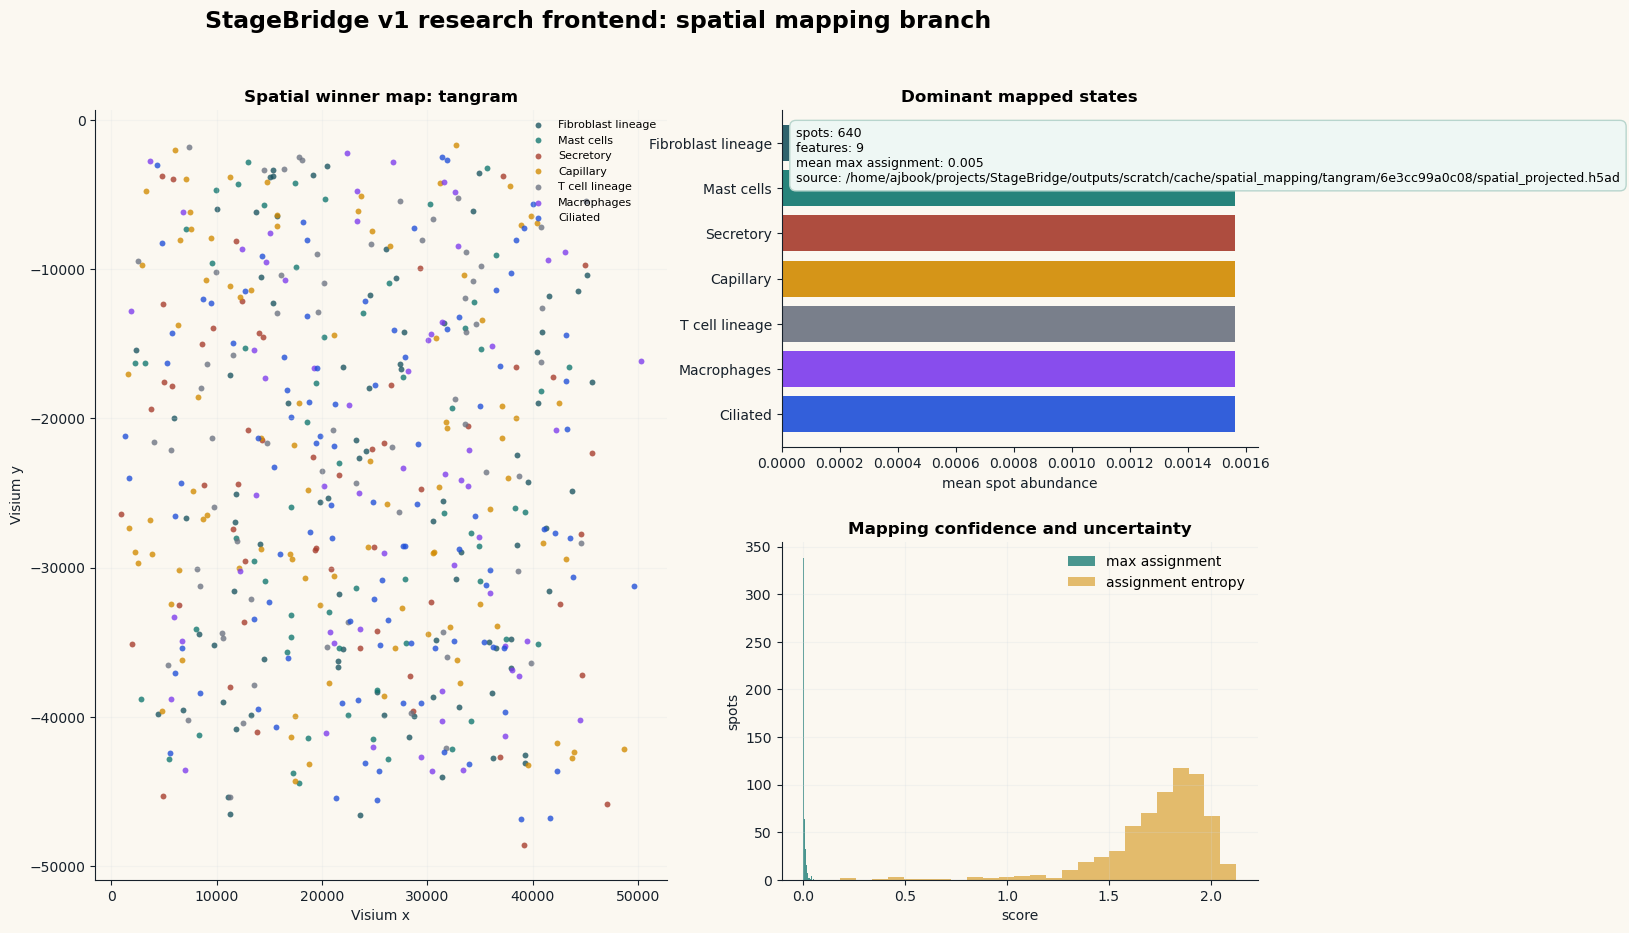

In [8]:
spatial_output = run_spatial_mapping(cfg_selected, reference_output=reference_output)
context_output = run_context_model(cfg_selected, spatial_output=spatial_output)

display(build_spatial_summary_table(spatial_output))
display(plot_spatial_mapping_frontend(spatial_output))

typed_tokens = context_output.get("typed_tokens")
if typed_tokens is not None:
    typed_summary = pd.DataFrame(list(typed_tokens.summary().items()), columns=["field", "value"])
    display(typed_summary)
else:
    display(Markdown("No typed tokens were built because the current mode is `rna_only`."))


## Step 9. Context Model and Transformer Diagnostics

**Purpose.** Inspect the context representation before transition fitting. This is where StageBridge decides whether it is operating in `rna_only`, `pooled`, `deep_sets`, `set_only`, `typed_hierarchical_transformer`, or `graph_of_sets` mode.

**Input.** The typed token object from Step 8 and the current context encoder configuration.

**Output.** A context summary table and a figure showing typed-group composition, dominant group structure over space, and context-branch diagnostics.

**QC checks.** Confirm the mode, token dimensions, context dimensionality, and whether a graph branch is actually active. At this stage the transformer has not yet been jointly trained with the transition model; that training-induced attention signal appears only after the transition fit.

**Relevant papers.** This step is where the competition between [Deep Sets](docs/papers/Deep%20Sets.pdf), [Set Transformer](docs/papers/Set%20Transformer%20A%20Framework%20for%20Attention-based%20Permutation-Invariant%20Neural%20Networks.pdf), and graph-augmented context models becomes concrete.

**Next step.** Fit the edge-wise transition model using this context branch and then inspect both performance and transformer-specific training diagnostics.


,metric,value
0,mode,typed_hierarchical_transformer
1,spatial_mapping_method,tangram
2,n_token_rows,640
3,token_dim,4
4,context_norm,12.648538
5,context_dim,160
6,mean_token_confidence,0.2064
7,example_context_tokens,7
8,dataset_name,luad_evo
9,dataset_embedding_enabled,True


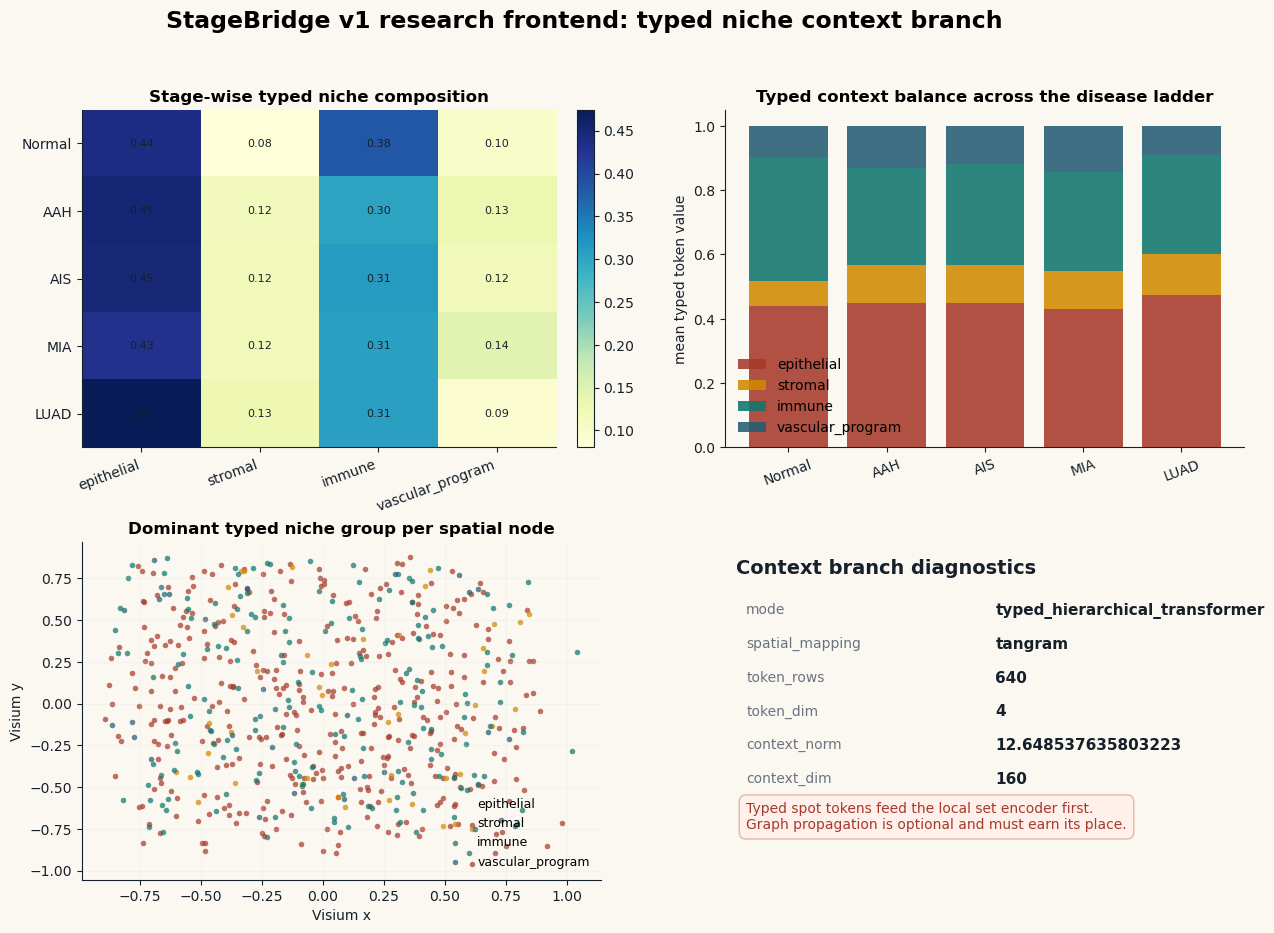

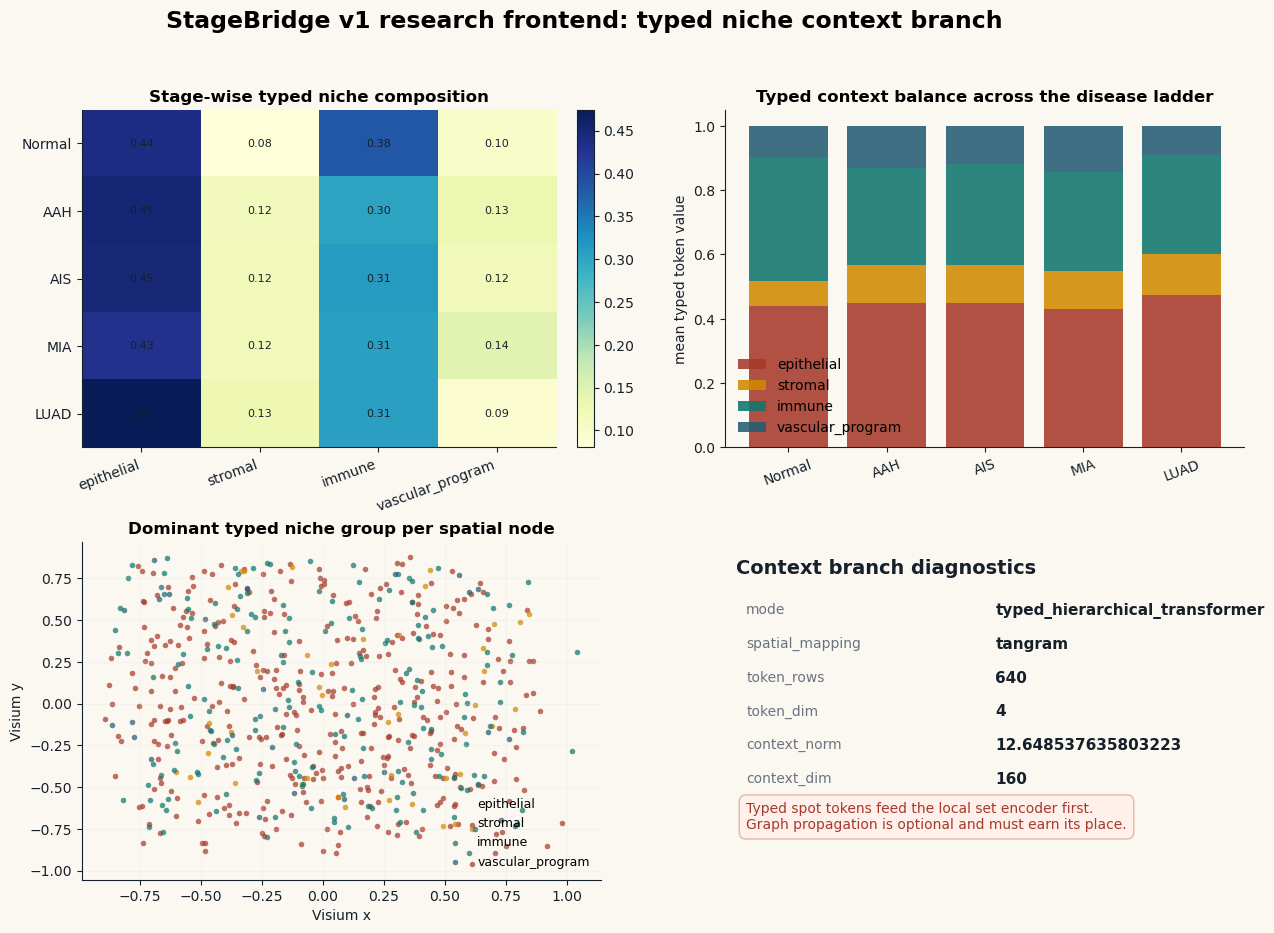

In [9]:
display(build_context_summary_table(context_output))
display(plot_context_frontend(context_output))


## Step 10. Transition Fit

**Purpose.** Fit the active edge-wise transition model for the selected edge using the selected provider and context representation.

**Input.** The reference latent, the selected provider output, the typed context branch, and the transition configuration under `stagebridge/transition_model/`.

**Output.** One transition payload containing the fitted model, held-out test tensors, split summary, WES diagnostics, training history, and any transformer attention summaries captured during joint training.

**QC checks.** Confirm the edge, split strategy, diffusion setting, and WES status before looking at downstream evaluation. This cell is the fit step only; the next cell is where quality is judged.

**Relevant papers.** The transition layer is motivated by [The Schrödinger Bridge between Gaussian Measures has a Closed Form](docs/papers/The%20Schr%C3%B6dinger%20Bridge%20between%20Gaussian%20Measures%20has%20a%20Closed%20Form.pdf) and the broader transport framing in [Optimal transport for single-cell and spatial omics: Primer](docs/papers/Optimal%20transport%20for%20single-cell%20and%20spatial%20omics-%20Primer.pdf).

**Next step.** Evaluate the fit, inspect the biological readout, and decide whether the current mode is actually earning its place.


In [10]:
transition_output = run_transition_model(
    cfg_selected,
    reference_output=reference_output,
    spatial_output=spatial_output,
    context_output=context_output,
)

transition_contract = pd.DataFrame(
    [
        {"field": "edge", "value": transition_output.get("edge")},
        {"field": "mode", "value": transition_output.get("mode")},
        {"field": "provider", "value": (transition_output.get("spatial_mapping") or {}).get("method")},
        {"field": "sigma", "value": transition_output.get("sigma")},
        {"field": "wes_enabled", "value": (transition_output.get("wes_diagnostics") or {}).get("enabled")},
        {"field": "split_strategy", "value": (transition_output.get("split_summary") or {}).get("split_strategy")},
    ]
)

display(transition_contract)


Starting preprocessing
Annotation profiles were not found in `reference.varm["hlca_label"]`. Constructing reference profiles with `tacco.preprocessing.construct_reference_profiles` and default arguments...
Finished preprocessing in 7.31 seconds.
Starting annotation of data with shape (640, 17776) and a reference of shape (36000, 17776) using the following wrapped method:
+- platform normalization: platform_iterations=0, gene_keys=hlca_label, normalize_to=adata
   +- bisection boost: bisections=4, bisection_divisor=3
      +- core: method=OT annotation_prior=None
mean,std( rescaling(gene) )  0.1711671176824388 0.6499694505590603
bisection run on 1
bisection run on 0.6666666666666667
Starting preprocessing
Finished preprocessing in 9.15 seconds.
Starting annotation of data with shape (640, 17776) and a reference of shape (36000, 17776) using the following wrapped method:
+- core: method=nnls annotation_prior=None
Finished annotation in 0.99 seconds.


INFO: Seed set to 42


2026-03-09 01:51:58 | INFO     | lightning.fabric.utilities.seed | Seed set to 42


INFO: GPU available: True (cuda), used: True


2026-03-09 01:52:00 | INFO     | lightning.pytorch.utilities.rank_zero | GPU available: True (cuda), used: True


...

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


2026-03-09 01:52:06 | INFO     | lightning.pytorch.accelerators.cuda | LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


INFO: `Trainer.fit` stopped: `max_epochs=2` reached.


2026-03-09 01:52:06 | INFO     | lightning.pytorch.utilities.rank_zero | `Trainer.fit` stopped: `max_epochs=2` reached.


,field,value
0,edge,AAH->AIS
1,mode,typed_hierarchical_transformer
2,provider,tangram
3,sigma,0.1
4,wes_enabled,True
5,split_strategy,stagewise_donor_holdout


## Step 11. Evaluation and Biology Readout

**Purpose.** Judge the current run using held-out metrics, calibration, context sensitivity, diffusion diagnostics, and the current typed-niche biological interpretation.

**Input.** The transition output from Step 10 and the context output from Step 9.

**Output.** One transition/evaluation summary table, one biology summary table, one gate-ready table, a transition-and-training figure, and a typed-group biology figure.

**QC checks.** This is where you decide whether the mode is merely runnable or scientifically useful. Look at Sinkhorn, calibration, context sensitivity, encoder parameter movement, attention summaries, and the dominant typed-group shifts. If those do not line up, the model is not earning a strong claim.

**Relevant papers.** The biological interpretation layer should be read conservatively. The purpose is to surface niche-shift candidates and testable patterns, not to overclaim that every latent transition is a true lineage or trajectory.

**Next step.** Write the run through the lightweight results system with the reference gate and provider benchmark artifacts attached so the notebook remains traceable after execution.


,metric,value
0,edge,AAH->AIS
1,mode,typed_hierarchical_transformer
2,sigma,0.1
3,diffusion_weight,0.2
4,split_strategy,stagewise_donor_holdout
5,same_donor_overlap,2
6,wes_enabled,True
7,wes_penalty_mean,2.643828
8,heldout_sinkhorn,14.842181
9,heldout_auc,0.333333


,metric,value
0,edge,AAH->AIS
1,dominant_increase_group,immune
2,dominant_decrease_group,vascular_program
3,split_strategy,stagewise_donor_holdout
4,n_overlap_donors,2
5,context_sensitivity_delta,-0.024296


,signal,value
0,sinkhorn,14.842181
1,context_sensitivity_delta,-0.024296
2,mean_diffusion_scale,0.493828
3,pseudotime_alignment,NaN


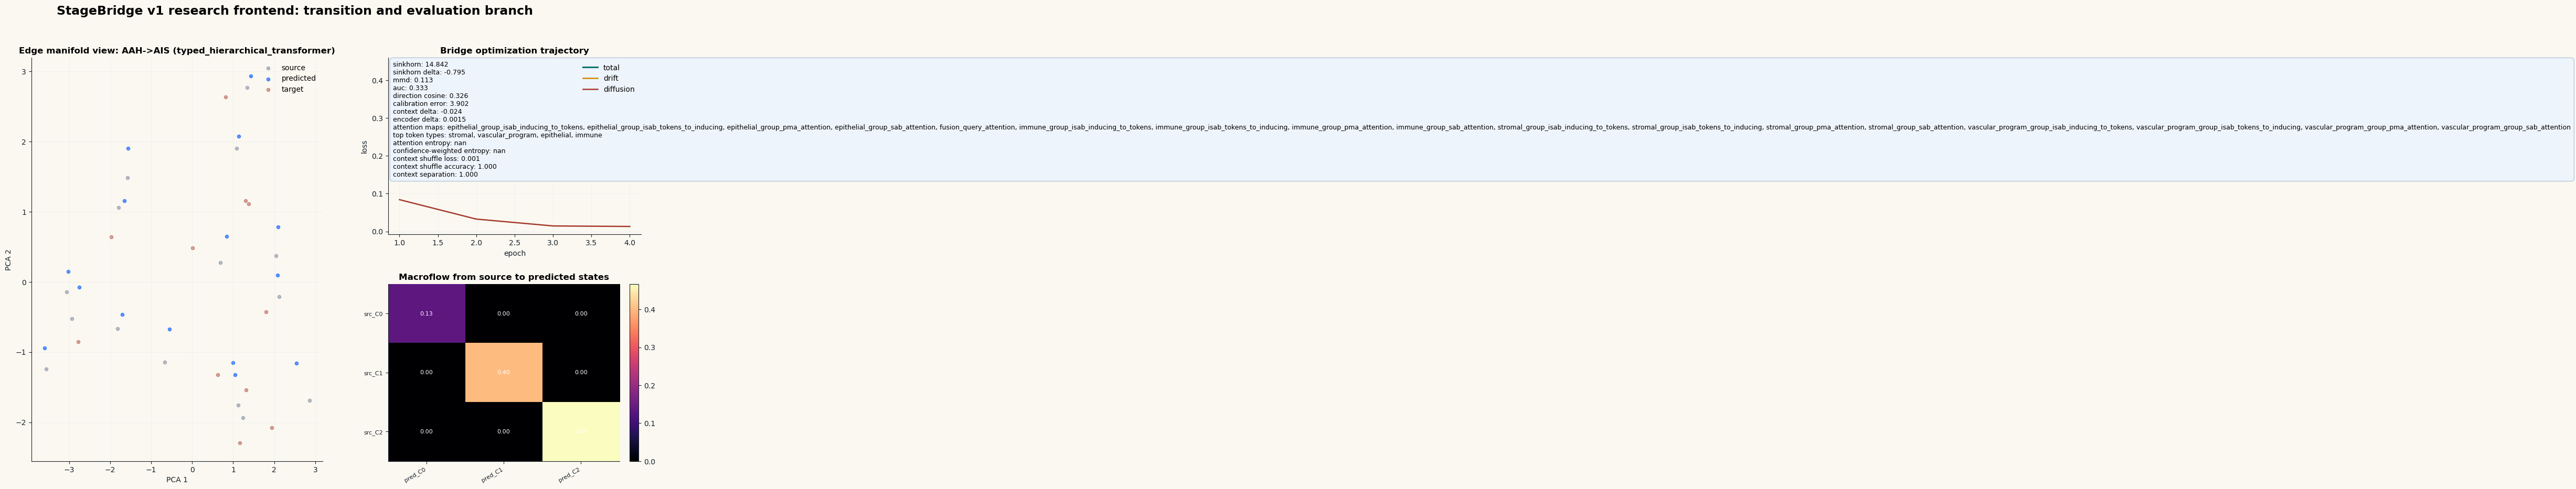

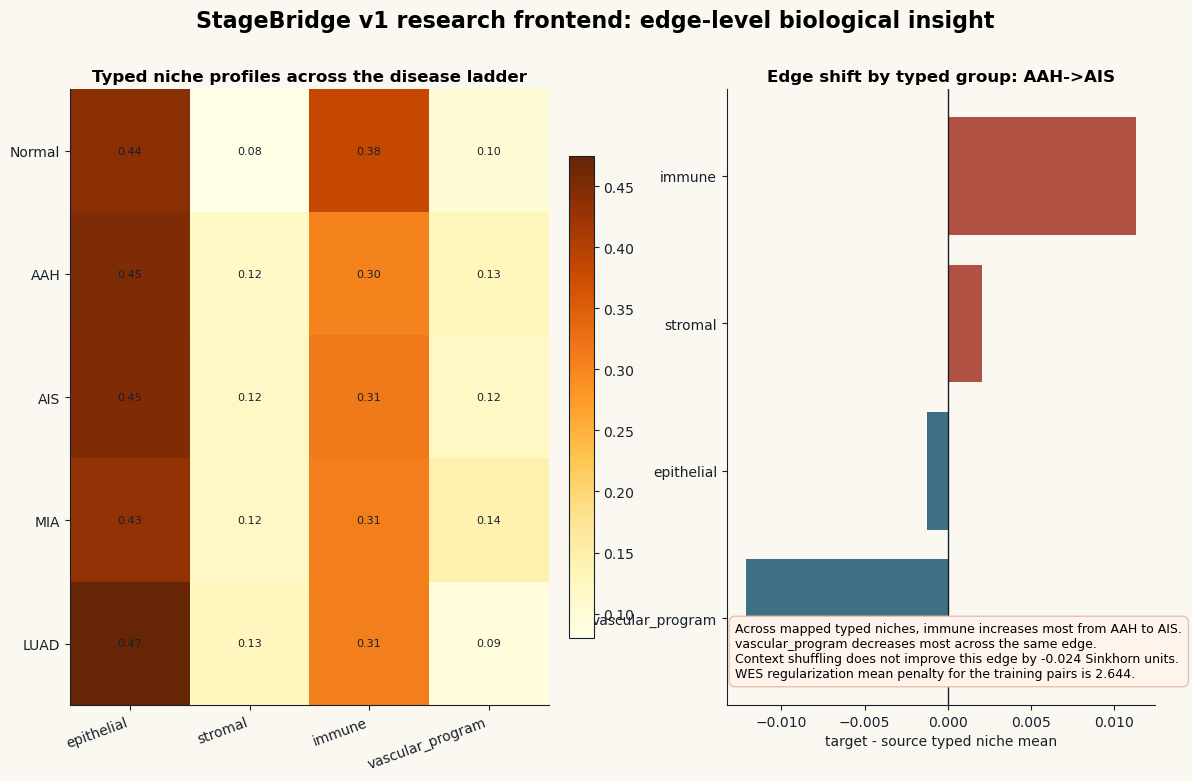

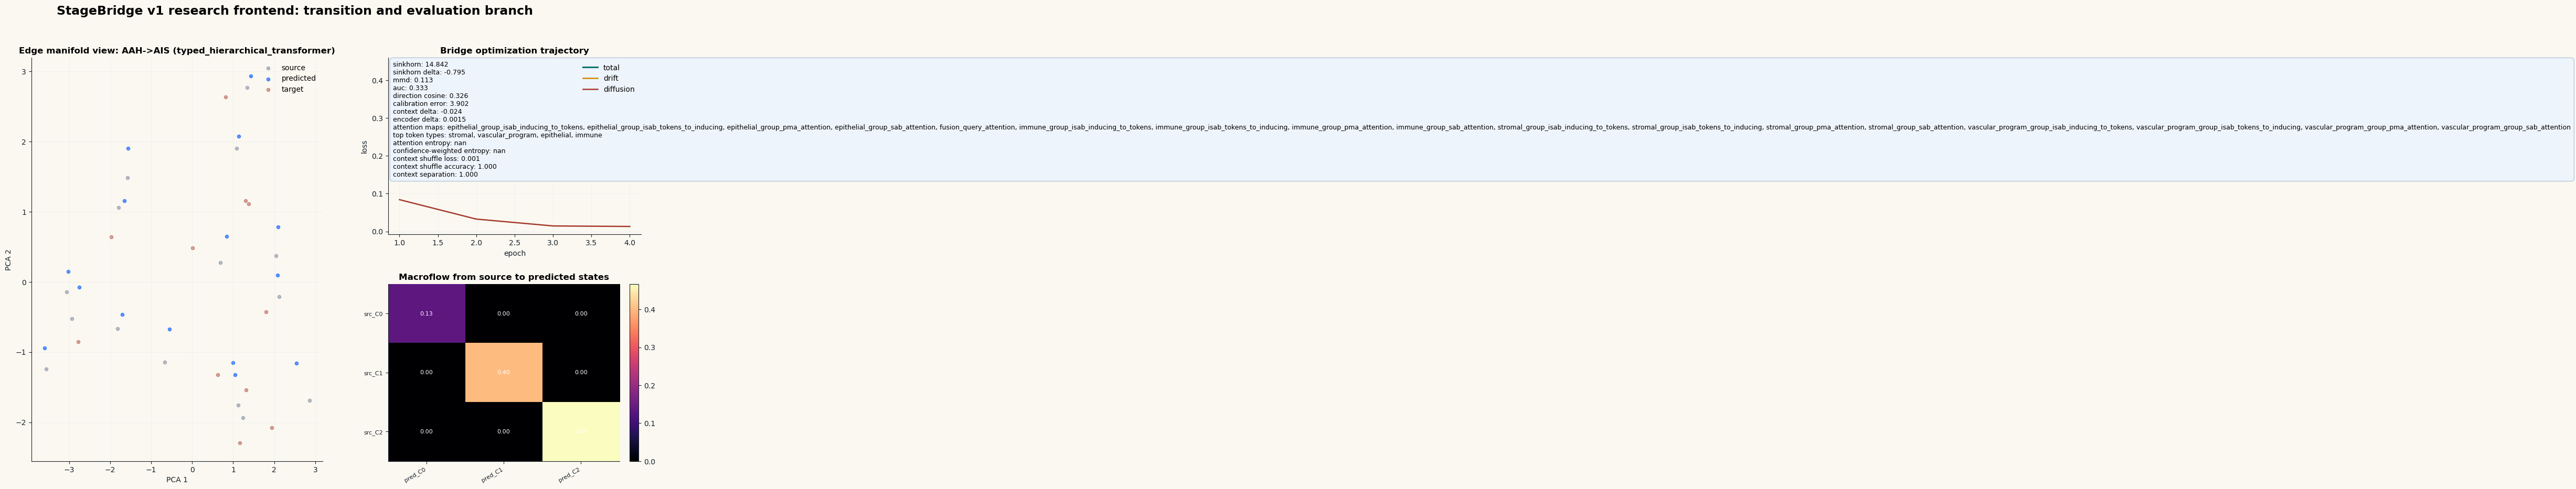

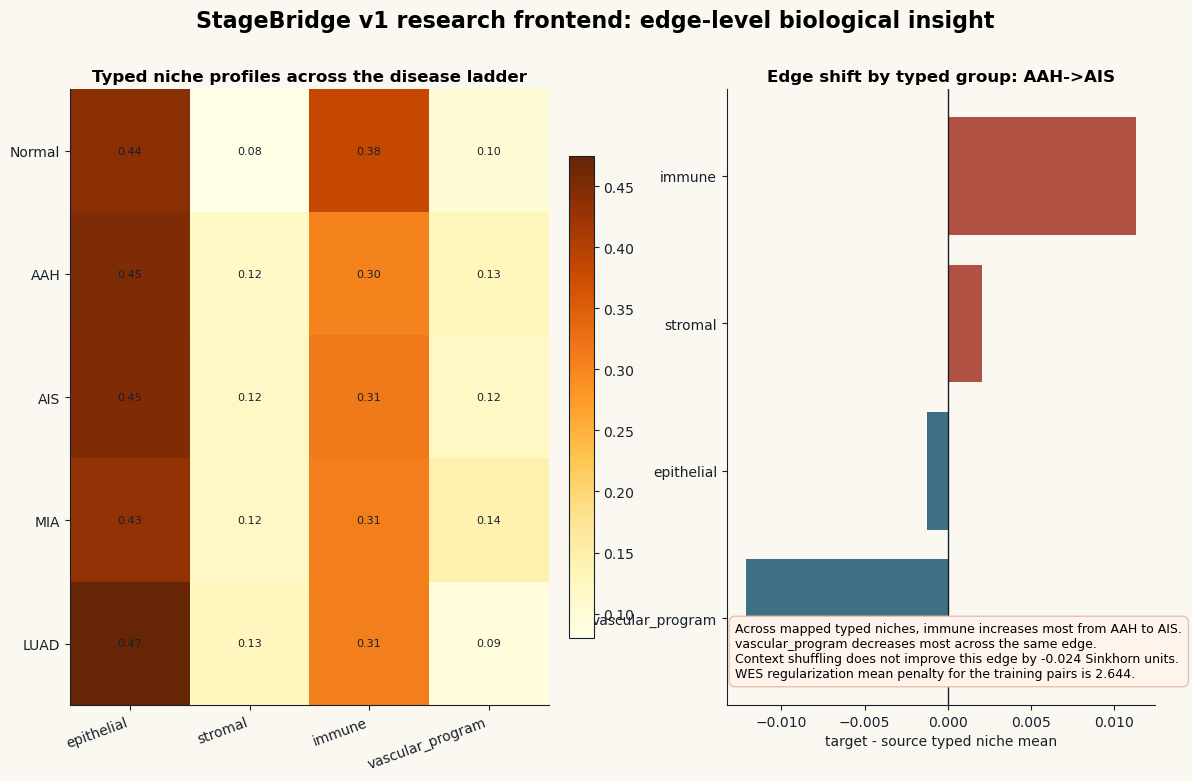

In [11]:
evaluation_output = run_evaluation(
    cfg_selected,
    transition_output=transition_output,
    context_output=context_output,
)

display(build_transition_summary_table(transition_output, evaluation_output))
display(build_biology_summary_table(evaluation_output))
display(build_gate_ready_table(evaluation_output))
display(plot_transition_frontend(transition_output, evaluation_output))
display(plot_biological_insight_frontend(evaluation_output))


## Step 12. Results Writeout and Registry

**Purpose.** Record the audited run in the active lightweight results system. Ordinary runs still write to the reusable scratch workspace, but the notebook should carry the gate outputs and provider-selection artifacts with it so the record is interpretable later.

**Input.** The stepwise outputs from this notebook, especially the reference gate, provider benchmark, transition evaluation, and biology readout.

**Output.** An updated scratch run, new registry row, visible current-scratch artifact listing, and a compact step-status summary.

**QC checks.** Confirm that the written run reflects the selected provider, current edge, current mode, and current benchmark outputs. The registry should be updated without creating permanent per-run sprawl.

**Next step.** If the run is genuinely strong, promote it intentionally. If it is weak or inconclusive, keep it in scratch/registry and improve the model rather than promoting noise.


In [12]:
pipeline_output = {
    "ok": True,
    "pipeline": "notebook_frontend",
    "steps": {
        "reference": reference_output,
        "spatial_mapping": spatial_output,
        "context_model": context_output,
        "transition_model": transition_output,
        "evaluation": evaluation_output,
    },
}

extra_artifacts = {
    "reference_alignment_gate.json": reference_output["reference"]["diagnostics"].get("alignment_gate", {}),
    "reference_alignment_summary.json": reference_output["reference"]["diagnostics"],
    "provider_benchmark.json": benchmark_output.get("benchmark", {}),
    "provider_benchmark.md": benchmark_output.get("benchmark_md", ""),
    "provider_metric_table.json": benchmark_output.get("provider_metric_table", pd.DataFrame()).to_dict(orient="records"),
    "provider_downstream_table.json": benchmark_output.get("provider_downstream_table", pd.DataFrame()).to_dict(orient="records"),
}

write_result = write_pipeline_scratch_run(
    cfg_selected,
    pipeline_output,
    notebook_source="StageBridge.ipynb",
    experiment_name=f"stagebridge_{selected_provider}_{transition_output.get('edge', 'edge')}",
    extra_artifact_sources=extra_artifacts,
)

scratch_payload = load_current_scratch_run()
registry_rows = read_results_registry()
registry_tail = pd.DataFrame(registry_rows).tail(12) if registry_rows else pd.DataFrame()

display(build_step_status_table(pipeline_output))
display(pd.DataFrame([write_result["run_metadata"]]))
display(registry_tail)
display(pd.DataFrame({"artifact": scratch_payload.get("artifacts", [])}))


,step,ok,status,pipeline
0,reference,True,complete,reference
1,spatial_mapping,True,complete,spatial_mapping
2,context_model,True,complete,context_model
3,transition_model,True,complete,transition_model
4,evaluation,True,complete,evaluation


,timestamp,git_commit,git_short_hash,git_branch,experiment_name,mode,stage_edges,seed,split_name,wes_regularizer_enabled,spatial_mapping_method,context_model_mode,notebook_source,status
0,2026-03-09T05:52:15.305854+00:00,70f7a6ca4e42ad17f6c053b19a20bd4761b35189,70f7a6c,main,stagebridge_tangram_AAH->AIS,typed_hierarchical_transformer,[AAH->AIS],42,donor_holdout,True,tangram,typed_hierarchical_transformer,StageBridge.ipynb,complete


,timestamp,git_commit,git_short_hash,git_branch,experiment_name,mode,stage_edges,split_name,wes_regularizer_enabled,spatial_mapping_method,context_model_mode,status,primary_metric,promoted,scratch_path,milestone_id
32,2026-03-08T02:36:26.123203+00:00,20e0d11e1a1858e58a27e1f0491c9af3fa3573d7,20e0d11,main,mission3_diffusion_gate_ais_to_mia,scientific_gates,AIS->MIA,donor_holdout,no,tangram,set_only,complete,16.212661743164062,no,outputs/scratch/current,
33,2026-03-08T02:37:44.837535+00:00,20e0d11e1a1858e58a27e1f0491c9af3fa3573d7,20e0d11,main,mission3_final_gate_summary,scientific_gates,AAH->AIS|AIS->MIA,donor_holdout,no,tangram,set_only,complete,,no,outputs/scratch/current,
34,2026-03-08T04:00:46.350351+00:00,20e0d11e1a1858e58a27e1f0491c9af3fa3573d7,20e0d11,main,AAH_to_AIS,set_only,AAH->AIS,donor_holdout,no,tangram,set_only,complete,26.88287353515625,no,outputs/scratch/current,
35,2026-03-08T04:02:18.139495+00:00,20e0d11e1a1858e58a27e1f0491c9af3fa3573d7,20e0d11,main,AAH_to_AIS,set_only,AAH->AIS,donor_holdout,no,tangram,set_only,complete,28.174846649169922,no,outputs/scratch/current,
36,2026-03-08T04:17:35.991371+00:00,20e0d11e1a1858e58a27e1f0491c9af3fa3573d7,20e0d11,main,AAH_to_AIS,set_only,AAH->AIS,donor_holdout,yes,tangram,set_only,complete,14.287663459777832,no,outputs/scratch/current,
37,2026-03-08T05:04:54.092269+00:00,20e0d11e1a1858e58a27e1f0491c9af3fa3573d7,20e0d11,main,set_only_ais_to_mia_baseline,set_only,AIS->MIA,donor_holdout,no,tangram,set_only,complete,26.628677368164062,no,outputs/scratch/current,
38,2026-03-08T06:11:13.190281+00:00,c28354a529ecd3b014627e455635385f36974ead,c28354a,main,AAH_to_AIS,set_only,AAH->AIS,donor_holdout,no,tangram,set_only,complete,28.19644546508789,no,outputs/scratch/current,
39,2026-03-08T06:12:48.162679+00:00,c28354a529ecd3b014627e455635385f36974ead,c28354a,main,AAH_to_AIS,set_only,AAH->AIS,donor_holdout,no,tangram,set_only,complete,26.964866638183594,no,outputs/scratch/current,
40,2026-03-08T06:58:09.062491+00:00,c28354a529ecd3b014627e455635385f36974ead,c28354a,main,AAH_to_AIS,set_only,AAH->AIS,donor_holdout,no,tangram,set_only,complete,27.445865631103516,no,outputs/scratch/current,
41,2026-03-08T07:04:35.310755+00:00,c28354a529ecd3b014627e455635385f36974ead,c28354a,main,AAH_to_AIS,set_only,AAH->AIS,donor_holdout,no,tangram,set_only,complete,27.001239776611328,no,outputs/scratch/current,


,artifact
0,artifacts/biology_summary.json
1,artifacts/calibration.json
2,artifacts/context_sensitivity.json
3,artifacts/dataset_transfer_diagnostics.json
4,artifacts/diffusion_diagnostics.json
5,artifacts/evaluation_report.json
6,artifacts/heldout_metrics.json
7,artifacts/niche_regimes.json
8,artifacts/pretraining_summary.json
9,artifacts/provider_benchmark.json


## Appendix. Current Interpretation Discipline

This notebook is designed to make it difficult to fool yourself. A run is not interesting because the transition code converged. A run becomes interesting only when the reference gate is defensible, the provider choice is justified or honestly inconclusive, the context mode beats simpler baselines, and the biological readout stays coherent under those constraints.

If the notebook shows weak or mixed evidence, that is a correct result, not a notebook failure.


## Appendix B. Optional Set Transformer Tuning After Upstream Validation

**Purpose.** Tune the `set_only` transformer only after the reference and provider gates have been inspected. This appendix is deliberately outside the main numbered protocol because tuning is downstream of truth-checking, not a substitute for it.

**Input.** The provider-selected config from Step 7. The study keeps `WES=false` and `sigma=0.0` so the Set Transformer is judged against simpler baselines without extra confounders.

**Output.** An Optuna study, a trial table, confirmation summaries on the best trial, and the standard optimization-history / importance / slice / parallel-coordinate figures.

**QC checks.** The tuned Set Transformer only earns flagship status if it beats `deep_sets` on both prioritized edges, or wins one edge strongly and the other weakly but stably.

**Relevant papers.** This is the point where the transformer story has to justify itself against [Deep Sets](docs/papers/Deep%20Sets.pdf) and the transformer-specific arguments in [Transformers in single-cell omics](docs/papers/Transformers%20in%20single-cell%20omics%20a%20review%20and%20new%20perspectives.pdf).


In [13]:
# This appendix is optional because it is substantially more expensive than the core
# truth-first protocol above. Run it only after the HLCA gate and provider benchmark
# are in a state you are willing to trust provisionally.

# tuning_output = run_set_only_optuna_study(
#     cfg_selected,
#     n_trials=12,
#     edges=["AAH->AIS", "AIS->MIA"],
#     search_seeds=[7, 13],
#     confirm_seeds=[7, 13, 29],
# )
# display(tuning_output["trial_table"])
# display(tuning_output["baseline_summary"])
# display(tuning_output["confirmed_table"])
# for figure in tuning_output["figure_bundle"].values():
#     display(figure)
# display(Markdown(tuning_output["interpretation"]))
